# Fine-tuning d’un modèle de triage médical — SFT puis DPO

Dans ce notebook, je construis une expérience reproductible autour de **Qwen3-1.7B-Base**. J’analyse mes données, j’entraîne d’abord le modèle en SFT, puis je poursuis avec un DPO et je compare les deux modèles sur **exactement le même jeu de test**.

J’utilise **Weights & Biases** pour suivre les paramètres, les pertes, les métriques, les prédictions et les artefacts. Ce travail reste un prototype pédagogique : il ne constitue pas un dispositif médical et ne doit pas être utilisé pour une décision clinique réelle.


## Table des matières

1. [Installation et imports](#1-installation-et-imports)
2. [Configuration reproductible](#2-configuration-reproductible)
3. [Chargement et normalisation](#3-chargement-et-normalisation)
4. [Audit des données](#4-audit-des-données)
8. [Préparation DPO](#8-préparation-dpo)
9. [Entraînement DPO](#9-entraînement-dpo)
10. [Évaluation complète DPO](#10-évaluation-complète-dpo)
11. [Comparaison SFT/DPO](#11-comparaison-sftdpo)
12. [Conclusion et manifeste](#12-conclusion-et-manifeste)


## 1. Installation et imports

J’installe les bibliothèques une seule fois dans l’environnement. Après cette cellule, je redémarre le noyau si Jupyter le demande, puis je poursuis l’exécution.


In [1]:
# ## 1. Imports
# ## Mode local Hugging Face

# Force Hugging Face, Transformers et Datasets à utiliser uniquement
# les modèles et fichiers déjà présents dans le cache local.
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

print("✓ Hugging Face : mode local/offline")


# Bibliothèque standard : mémoire, fichiers, empreintes et environnement système.
import gc
import hashlib
import json
import sys
import platform

from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path


# Tests statistiques utilisés pour comparer les performances des modèles.
from scipy.stats import binomtest


# Chargement des variables d'environnement depuis le fichier .env.
from dotenv import load_dotenv


# Unsloth : chargement optimisé de Qwen3 et du modèle quantifié 4-bit.
from unsloth import FastModel


# Calcul numérique, manipulation des datasets et entraînement GPU.
import numpy as np
import pandas as pd
import torch
import wandb

from datasets import Dataset
from peft import PeftModel


# Métriques utilisées pour l'évaluation métier P1/P2/P3.
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)


# Barres de progression compatibles notebook.
from tqdm.auto import tqdm


# Transformers : entraînement, configuration et reproductibilité.
from transformers import (
    EarlyStoppingCallback,
    PreTrainedTokenizerBase,
    Trainer,
    TrainingArguments,
    set_seed
)


# Affichage des courbes et matrices de confusion.
import matplotlib.pyplot as plt


# Fonctions PyTorch utilisées pour les calculs de probabilités et de loss.
import torch.nn.functional as F


# Callback de progression spécifique aux notebooks.
from transformers.utils.notebook import NotebookProgressCallback

✓ Hugging Face : mode local/offline
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W1008 19:04:49.931000 22736 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
# Configuration centralisée et reproductible de l'expérience SFT + DPO.
# Tous les hyperparamètres importants sont regroupés pour faciliter l'audit du run.

@dataclass(frozen=True)
class ExperimentConfig:
    # Seed commune aux opérations aléatoires pour rendre les expériences reproductibles.
    seed: int = 42

    # Modèle

    # Modèle de base Qwen3 utilisé avant application des adapters SFT puis DPO.
    model_id: str = "Qwen/Qwen3-1.7B-Base"
    model_revision: str = "main"

    # Datasets

    # Taille cible historique du dataset DPO avant application des filtres/fractions.
    dpo_target: int = 2_307

    # Proportions réservées aux splits test et validation.
    test_size: float = 0.10
    validation_size: float = 0.10

    # Longueurs

    # Longueur maximale totale acceptée pour les séquences DPO.
    dpo_max_length: int = 2_048

    # Nombre maximal de nouveaux tokens autorisés en génération libre.
    generation_max_new_tokens: int = 512

    # DPO

    # Micro-batch réellement chargé en VRAM à chaque forward/backward.
    dpo_train_batch_size: int = 1
    dpo_eval_batch_size: int = 1

    # Accumule 8 micro-batches avant chaque mise à jour des poids.
    # Batch effectif = 1 × 8 = 8 exemples par optimizer step.
    dpo_gradient_accumulation: int = 8

    # Un seul passage sur le dataset pour limiter le surapprentissage observé.
    dpo_epochs: float = 1.0

    # Learning rate volontairement faible pour ajuster le SFT sans déplacement brutal.
    dpo_learning_rate: float = 5e-6

    # Contrôle la force de la préférence DPO par rapport au modèle de référence.
    dpo_beta: float = 0.10

    # Warmup sur les premiers 5 % des optimizer steps puis décroissance cosine.
    dpo_warmup_ratio: float = 0.05
    dpo_lr_scheduler_type: str = "cosine"

    # Réduit fortement la consommation VRAM en recalculant certaines activations.
    # Utile sur la RTX 4050 6 Go, au prix d'un entraînement plus lent.
    dpo_gradient_checkpointing: bool = True

    # Suivi

    # Fréquence d'enregistrement des métriques d'entraînement.
    logging_steps: int = 10

    # Lance la validation complète tous les 50 optimizer steps.
    eval_steps: int = 20

    # Sauvegarde un checkpoint tous les 50 optimizer steps.
    save_steps: int = 20

    # Active la traçabilité des expériences dans Weights & Biases.
    wandb_enabled: bool = True
    wandb_project: str = "medical-triage-qwen3"

    # Contrôles datasets

    # Rend bloquantes les incohérences de taille détectées dans les datasets.
    strict_dataset_sizes: bool = True

    # Vérifie que les priorités P1/P2/P3 restent suffisamment équilibrées.
    require_balanced_priorities: bool = True

    # Tolérance maximale admise pour le déséquilibre entre priorités.
    priority_balance_tolerance: float = 0.02

    # Smoke test

    # Active un entraînement miniature pour valider la pipeline avant un run complet.
    smoke: bool = False

    # Nombre de lignes utilisées lorsque le smoke test est activé.
    smoke_train_rows: int = 32
    smoke_validation_rows: int = 16

    # Limite le smoke test à deux optimizer steps.
    smoke_max_steps: int = 2

    # Fraction du DPO

    # Fraction des données DPO retenue par la pipeline.
    # 0.2 = 20 %, 0.5 = 50 %, 1.0 = totalité du dataset disponible.
    dpo_fraction: float = 0.2


# Instancie une configuration immuable commune à l'ensemble du notebook.
CONFIG = ExperimentConfig()


# Fixe les seeds utilisées par Transformers/PyTorch pour améliorer la reproductibilité.
set_seed(CONFIG.seed)

print(f"✓ Seed : {CONFIG.seed}")

✓ Seed : 42


In [3]:
# ## Chemins et configuration du run SFT + DPO

# Remonte depuis le dossier courant jusqu'à identifier la structure du projet.
# La présence de data/raw/datasets sert de marqueur fiable de la racine.
def find_project_root(start: Path | None = None) -> Path:
    """Localise la racine du projet."""
    path = (start or Path.cwd()).resolve()

    for root in (path, *path.parents):
        if (root / "data" / "raw" / "datasets").is_dir():
            return root

    raise FileNotFoundError("Racine du projet introuvable.")


# Chemins

# Centralise les répertoires utilisés par les datasets et les artefacts du fine-tuning.
PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "datasets"
SPLIT_DIR = DATASET_DIR / "splits"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"

METRIC_DIR = OUTPUT_DIR / "metrics"  # Métriques et résultats d'évaluation.
MODEL_DIR = OUTPUT_DIR / "models"    # Checkpoints et adapters entraînés.

# Splits SFT figés : train, validation et test final commun SFT/DPO.
SFT_TRAIN_PATH = SPLIT_DIR / "sft_train.jsonl"
SFT_VALIDATION_PATH = SPLIT_DIR / "sft_validation.jsonl"
SFT_TEST_PATH = SPLIT_DIR / "sft_test.jsonl"

# Paires chosen/rejected utilisées pour l'entraînement et la validation DPO.
DPO_TRAIN_PATH = SPLIT_DIR / "dpo_train.jsonl"
DPO_VALIDATION_PATH = SPLIT_DIR / "dpo_validation.jsonl"


# Run SFT + DPO

# Identifie précisément le run SFT servant de point de départ au DPO.
# Le checkpoint sélectionné devient la référence et la policy initiale du DPO.
SFT_SOURCE_STAMP = "20261007-003909"
SFT_SOURCE_CHECKPOINT = "checkpoint-950"

# Le DPO reste rattaché au même identifiant expérimental que son SFT source.
RUN_STAMP = SFT_SOURCE_STAMP
RUN_GROUP = f"qwen3-triage-{RUN_STAMP}"  # Groupe commun utilisé notamment dans W&B.

# Répertoires propres à cette expérience.
RUN_MODEL_DIR = MODEL_DIR / RUN_STAMP
RUN_METRIC_DIR = METRIC_DIR / RUN_STAMP

# Checkpoint SFT exact utilisé pour initialiser et référencer le DPO.
SFT_SOURCE_PATH = (
    RUN_MODEL_DIR / "sft_checkpoints" / SFT_SOURCE_CHECKPOINT
)

# Répertoires dédiés aux checkpoints intermédiaires et à l'adapter DPO final.
DPO_CHECKPOINT_DIR = RUN_MODEL_DIR / "dpo_checkpoints"
DPO_MODEL_PATH = RUN_MODEL_DIR / "dpo_adapter"


# Reprise DPO

# False = nouveau DPO ; True = reprise depuis un checkpoint DPO existant.
DPO_RESUME = False
DPO_RESUME_CHECKPOINT = None

# Construit le chemin de reprise uniquement lorsque celle-ci est activée.
DPO_RESUME_PATH = (
    DPO_CHECKPOINT_DIR / DPO_RESUME_CHECKPOINT
    if DPO_RESUME
    else None
)


# Environnement + W&B

# Charge les secrets et paramètres W&B depuis le .env situé à la racine.
load_dotenv(PROJECT_ROOT / ".env")

WANDB_MODE = os.getenv("WANDB_MODE", "online")                     # online / offline / disabled.
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None                   # Compte ou organisation W&B.
WANDB_PROJECT = os.getenv("WANDB_PROJECT", CONFIG.wandb_project)   # Projet W&B cible.
WANDB_API_KEY = os.getenv("WANDB_API_KEY")                         # Clé requise en mode online.

# W&B est utilisé uniquement s'il est activé dans CONFIG et non désactivé par l'environnement.
USE_WANDB = (
    CONFIG.wandb_enabled
    and WANDB_MODE != "disabled"
)

# Évite de lancer un run online sans authentification disponible.
if USE_WANDB and WANDB_MODE == "online" and not WANDB_API_KEY:
    raise RuntimeError("WANDB_API_KEY absente.")

# Valeur transmise aux TrainingArguments pour activer ou couper le reporting.
REPORT_TO = ["wandb"] if USE_WANDB else "none"


# Initialise un run W&B pour une étape précise : DPO, test, benchmark, etc.
# CONFIG est enregistré automatiquement puis enrichi avec les métadonnées du stage.
def start_wandb_run(stage: str, extra: dict | None = None):
    """Démarre le suivi W&B."""
    if not USE_WANDB:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{stage}-{RUN_STAMP}",                     # Nom lisible du run.
        group=RUN_GROUP,                                 # Regroupe SFT/DPO/tests associés.
        job_type=stage,                                  # Nature de l'étape exécutée.
        tags=["qwen3", "medical-triage", stage],
        config=asdict(CONFIG) | (extra or {}),           # Configuration + métadonnées spécifiques.
        mode=WANDB_MODE,
        reinit="finish_previous",                        # Ferme proprement le run précédent.
    )


# Contrôles

# Regroupe les cinq datasets indispensables au pipeline.
# Chaque chemin est vérifié avant tout chargement ou entraînement.
DATASET_PATHS = {
    "SFT train": SFT_TRAIN_PATH,
    "SFT validation": SFT_VALIDATION_PATH,
    "SFT test": SFT_TEST_PATH,
    "DPO train": DPO_TRAIN_PATH,
    "DPO validation": DPO_VALIDATION_PATH,
}

# Recherche en une seule passe tous les fichiers absents.
missing = [
    f"{name}: {path}"
    for name, path in DATASET_PATHS.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        "Datasets introuvables :\n" + "\n".join(missing)
    )


# Vérifie que le checkpoint SFT choisi comme source existe réellement.
if not SFT_SOURCE_PATH.is_dir():
    raise FileNotFoundError(
        f"Checkpoint SFT introuvable : {SFT_SOURCE_PATH}"
    )


# Une reprise DPO nécessite obligatoirement le nom explicite du checkpoint.
if DPO_RESUME and not DPO_RESUME_CHECKPOINT:
    raise ValueError(
        "DPO_RESUME_CHECKPOINT requis pour reprendre le DPO."
    )


# Vérifie également l'existence physique du checkpoint demandé pour la reprise.
if DPO_RESUME and not DPO_RESUME_PATH.is_dir():
    raise FileNotFoundError(
        f"Checkpoint DPO introuvable : {DPO_RESUME_PATH}"
    )


# Crée les répertoires de sortie nécessaires sans erreur s'ils existent déjà.
for path in (
    RUN_METRIC_DIR,       # Métriques et résultats du run.
    RUN_MODEL_DIR,        # Modèles et adapters du run.
    DPO_CHECKPOINT_DIR,   # Checkpoints intermédiaires DPO.
):
    path.mkdir(parents=True, exist_ok=True)


# Résumé

# Affiche les informations essentielles avant le démarrage du pipeline.
print(
    f"✓ Run SFT + DPO : {RUN_STAMP}\n"
    f"✓ SFT source    : {SFT_SOURCE_CHECKPOINT}\n"
    f"✓ DPO           : {'REPRISE' if DPO_RESUME else 'NOUVEAU'}\n"
    f"✓ Datasets      : {len(DATASET_PATHS)}/{len(DATASET_PATHS)}\n"
    f"✓ W&B           : {'activé' if USE_WANDB else 'désactivé'}"
)

✓ Run SFT + DPO : 20261007-003909
✓ SFT source    : checkpoint-950
✓ DPO           : NOUVEAU
✓ Datasets      : 5/5
✓ W&B           : activé


## utilitaires JSONL et normalisation

In [4]:
# ## Utilitaires JSONL et normalisation

# Charge un fichier JSONL en ignorant les lignes vides.
# Chaque ligne non vide doit contenir exactement un objet JSON.
def read_jsonl(path: Path) -> list[dict]:
    """Charge un JSONL."""
    records = []

    with path.open(encoding="utf-8") as file:
        for n, line in enumerate(file, 1):
            if not line.strip():
                continue

            record = json.loads(line)

            # Sécurise le schéma minimal : chaque entrée doit être un dictionnaire.
            if not isinstance(record, dict):
                raise ValueError(f"Objet JSON attendu ligne {n}: {path}")

            records.append(record)

    return records


# Écrit une liste de dictionnaires au format JSONL UTF-8.
# Un enregistrement est sérialisé par ligne sans échapper les caractères Unicode.
def write_jsonl(path: Path, records: list[dict]) -> None:
    """Écrit un JSONL."""
    path.parent.mkdir(parents=True, exist_ok=True)  # Crée le dossier si nécessaire.

    with path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )


# Calcule l'empreinte SHA-256 d'un fichier sans le charger entièrement en mémoire.
# Utilisée pour tracer précisément les datasets associés à chaque expérience.
def file_sha256(path: Path) -> str:
    """Calcule le SHA-256."""
    digest = hashlib.sha256()

    # Lecture par blocs de 1 Mio adaptée aux fichiers potentiellement volumineux.
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024**2), b""):
            digest.update(chunk)

    return digest.hexdigest()


# Convertit les différents formats de données cliniques en texte exploitable.
# Les valeurs absentes deviennent une chaîne vide plutôt que "None".
def clinical_text(value) -> str:
    """Convertit une valeur clinique en texte."""
    if value is None:
        return ""

    # Nettoie directement les chaînes déjà textuelles.
    if isinstance(value, str):
        return value.strip()

    # Préserve la structure des objets et listes en les sérialisant en JSON.
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False) if value else ""

    # Convertit les autres types puis supprime les espaces périphériques.
    return str(value).strip()


# Normalise la langue pour ne conserver que les deux langues du dataset.
# Toute valeur absente ou non reconnue devient une chaîne vide.
def normalize_language(value) -> str:
    """Normalise fr/en."""
    value = str(value or "").strip().lower()

    return value if value in {"fr", "en"} else ""


# Convertit les différentes représentations P1/P2/P3 vers les entiers 1/2/3.
# Retourne None lorsqu'une priorité est absente, invalide ou hors échelle.
def normalize_priority(value) -> int | None:
    """Normalise P1/P2/P3 en 1/2/3."""
    try:
        # Accepte aussi bien 1, "1", "P1" ou "p1".
        value = int(
            str(value).upper().replace("P", "").strip()
        )
    except (TypeError, ValueError):
        return None

    # Bloque toute classe extérieure à l'échelle de triage utilisée.
    return value if value in {1, 2, 3} else None

## prompt, tokenisation et hash

In [ ]:
# Prompts système SFT : même tâche de triage en français et en anglais.

# Prompts système communs SFT / DPO.
# La priorité dépend du délai de prise en charge justifié par le cas.

SYSTEM_PROMPTS = {
    "fr": (
        "Tu es un assistant de triage médical destiné à un service d'urgence. "
        "Ta mission est d'organiser la prise en charge des patients selon la gravité actuelle "
        "de leur situation clinique et leur risque de gravité ou d'aggravation. "
        "Classe obligatoirement chaque patient dans une seule priorité : "
        "P1 = urgence maximale : situation grave ou à haut risque de gravité nécessitant une prise "
        "en charge immédiate ou prioritaire, notamment en cas de menace vitale ou fonctionnelle, "
        "d'instabilité, de détresse majeure ou de risque important d'évolution grave ; "
        "P2 = urgence modérée : situation nécessitant une prise en charge médicale rapide en raison "
        "de sa gravité, de symptômes significatifs ou d'un risque clinique réel, sans nécessité "
        "de prise en charge aussi immédiate qu'une P1 ; "
        "P3 = urgence différée : patient présent aux urgences dont la situation est peu grave, "
        "stable et sans risque important de gravité ou d'aggravation identifié dans les données. "
        "La priorité doit tenir compte à la fois de l'état actuel du patient et du risque clinique "
        "associé à la situation décrite. "
        "Évalue uniquement les informations disponibles dans le cas fourni. "
        "Ne suppose aucune information absente et n'invente aucun symptôme, diagnostic ou élément patient. "
        "Fournis une explication claire et concise justifiant la priorité à partir des éléments disponibles. "
        "L'explication ne doit pas dépasser 200 mots. "
        "Réponds exactement sur deux lignes, en remplaçant <P1/P2/P3> par une seule priorité :\n"
        "PRIORITY: <P1/P2/P3>\n"
        "EXPLANATION: <explication claire justifiant la priorité>"
    ),
    "en": (
        "You are a medical triage assistant for an emergency department. "
        "Your task is to organize patient care according to both the current severity of the clinical "
        "situation and the risk of severity or deterioration. "
        "Classify each patient into exactly one priority: "
        "P1 = maximum urgency: severe or high-risk situation requiring immediate or priority care, "
        "including a threat to life or function, instability, major distress, or a significant risk "
        "of severe deterioration; "
        "P2 = moderate urgency: situation requiring prompt medical care because of its severity, "
        "significant symptoms, or a genuine clinical risk, without requiring care as immediately as P1; "
        "P3 = deferred urgency: patient presenting to the emergency department with a low-severity, "
        "stable situation and no significant risk of severity or deterioration identified in the data. "
        "The priority must account for both the patient's current condition and the clinical risk "
        "associated with the situation described. "
        "Assess only the information available in the provided case. "
        "Do not assume missing information or invent symptoms, diagnoses, or patient details. "
        "Provide a clear and concise explanation justifying the priority from the available information. "
        "The explanation must not exceed 200 words. "
        "Answer exactly in the following format:\n"
        "Answer in exactly two lines, replacing <P1/P2/P3> with a single priority:\n"
        "PRIORITY: <P1/P2/P3>\n"
        "EXPLANATION: <clear explanation justifying the priority>"
    )
}

# Prépare les entrées cliniques et les prompts utilisés par le DPO.
# Le contexte transmis au modèle provient directement du model_context final.

# Construit l'entrée utilisateur envoyée à Qwen depuis le contexte clinique.
# Refuse explicitement les cas sans contexte afin d'éviter un entraînement invalide.

def clinical_input(row: pd.Series) -> str:
    """Construit l'entrée envoyée à Qwen."""
    context = clinical_text(row["model_context"])                   # Contexte unifié

    if not context:
        raise ValueError(f"Contexte clinique vide : {row.get('id', 'inconnu')}")

    label = (
        "Informations médicales à analyser"
        if row["language"] == "fr"
        else "Medical information to analyze"
    )

    return f"{label}:\n{context}"

# Sélectionne le prompt système correspondant à la langue du cas.
# SYSTEM_PROMPTS contient les instructions distinctes pour le français et l'anglais.
def system_prompt(language: str) -> str:
    """Retourne le prompt système."""
    return SYSTEM_PROMPTS[language]                                 # Prompt FR / EN


# ## Construction des paires DPO finales

# Transforme une ligne du dataset DPO en structure prompt/chosen/rejected.
# Chaque paire contient le même cas clinique et deux réponses à comparer.
def build_dpo_example(row: pd.Series) -> dict:
    """Construit une paire DPO depuis le dataset final."""
    language = row["language"]

    # Récupère les priorités associées aux réponses préférée et rejetée.
    chosen_priority = int(row["chosen_priority"])
    rejected_priority = int(row["rejected_priority"])

    # Nettoie les explications avant leur insertion dans les réponses assistant.
    chosen_explanation = str(row["chosen_explanation"]).strip()
    rejected_explanation = str(row["rejected_explanation"]).strip()

    # Vérifie que la réponse préférée utilise une priorité valide P1/P2/P3.
    if chosen_priority not in (1, 2, 3):
        raise ValueError(
            f"{row['id']}: chosen_priority invalide P{chosen_priority}."
        )

    # Vérifie également la priorité portée par la réponse rejetée.
    if rejected_priority not in (1, 2, 3):
        raise ValueError(
            f"{row['id']}: rejected_priority invalide P{rejected_priority}."
        )

    # Une paire DPO nécessite deux explications non vides pour être exploitable.
    if not chosen_explanation or not rejected_explanation:
        raise ValueError(
            f"{row['id']}: explanation vide."
        )

    # Produit le format conversationnel attendu par le DPOTrainer :
    # un prompt commun puis une réponse chosen et une réponse rejected.
    return {
        "id": row["id"],
        "language": language,
        "priority": chosen_priority,                  # Priorité de la réponse préférée.
        "rejected_priority": rejected_priority,       # Priorité de la réponse rejetée.

        # Prompt identique pour chosen et rejected : système + cas clinique.
        "prompt": [
            {
                "role": "system",
                "content": system_prompt(language),   # Instructions de triage FR/EN.
            },
            {
                "role": "user",
                "content": clinical_input(row),       # Contexte clinique du patient.
            },
        ],

        # Réponse que le DPO doit apprendre à favoriser.
        # Le format reproduit la sortie attendue : PRIORITY puis EXPLANATION.
        "chosen": [{
            "role": "assistant",
            "content": (
                f"PRIORITY: P{chosen_priority}\n"
                f"EXPLANATION: {chosen_explanation}"
            ),
        }],

        # Réponse que le DPO doit apprendre à défavoriser pour le même prompt.
        "rejected": [{
            "role": "assistant",
            "content": (
                f"PRIORITY: P{rejected_priority}\n"
                f"EXPLANATION: {rejected_explanation}"
            ),
        }],
    }

In [6]:
# Normalise les différents formats possibles renvoyés par un tokenizer.
# Retourne toujours une liste Python simple contenant uniquement des IDs entiers.
def token_ids(value) -> list[int]:
    """Retourne une liste Python d'IDs."""

    # Extrait input_ids selon le type d'objet retourné par le tokenizer.
    if hasattr(value, "input_ids"):
        value = value.input_ids
    elif hasattr(value, "ids"):
        value = value.ids
    elif hasattr(value, "get") and value.get("input_ids") is not None:
        value = value["input_ids"]

    # Convertit un éventuel Tensor PyTorch en structure Python.
    if torch.is_tensor(value):
        value = value.tolist()

    # Retire la dimension batch lorsqu'une seule séquence est présente.
    if value and isinstance(value[0], (list, tuple)):
        value = value[0]

    # Vérifie que la sortie obtenue possède bien une structure séquentielle.
    if not isinstance(value, (list, tuple)):
        raise TypeError(f"Sortie tokenizer inattendue : {type(value)}")

    # Garantit que chaque élément correspond réellement à un token ID entier.
    if not all(isinstance(token, int) for token in value):
        kind = type(value[0]) if value else "vide"
        raise TypeError(f"input_ids invalides : {kind}")

    return list(value)  # Format final standardisé : list[int].


# Tokenise un texte déjà formaté sans ajouter de nouveaux tokens spéciaux.
# Important lorsque le chat template Qwen3 a déjà inséré ses propres marqueurs.
def tokenize_text(tokenizer, text: str) -> list[int]:
    """Tokenise un texte formaté."""
    return tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]                                                   # IDs uniquement.


# Applique le chat template natif de Qwen3 et retourne le prompt sous forme de texte.
# Le mode thinking est désactivé pour conserver le format PRIORITY + EXPLANATION attendu.
def render_chat(tokenizer, messages: list[dict], generation: bool = False) -> str:
    """Applique le template Qwen3 sans thinking."""

    # Paramètres communs au rendu des prompts SFT/DPO et d'inférence.
    kwargs = {
        "tokenize": False,                                           # Retourne du texte, pas des IDs.
        "add_generation_prompt": generation,                         # Ajoute le préfixe assistant si nécessaire.
        "enable_thinking": False                                     # Désactive le raisonnement Qwen3.
    }

    # Utilise enable_thinking lorsque le tokenizer installé le supporte.
    try:
        return tokenizer.apply_chat_template(messages, **kwargs)

    # Compatibilité avec une version de tokenizer ne connaissant pas enable_thinking.
    except TypeError:
        kwargs.pop("enable_thinking")
        return tokenizer.apply_chat_template(messages, **kwargs)

In [7]:
# ## Métriques et sauvegarde des évaluations

# Calcule la proportion de cas pour lesquels le modèle attribue une priorité
# moins urgente que la priorité attendue : P1→P2/P3 ou P2→P3.
def undertriage_rate(expected, predicted) -> float:
    """Calcule le taux global de sous-triage."""
    expected = pd.Series(expected).astype(int)
    predicted = pd.Series(predicted).astype(int)

    # Dans l'échelle utilisée : 1 = urgence maximale et 3 = urgence différée.
    return float((predicted > expected).mean())


# Calcule les performances globales et les performances propres à P1/P2/P3.
# Les résultats servent de base commune aux benchmarks SFT et DPO.
def evaluate_predictions(results: pd.DataFrame, stage: str):
    """Calcule les métriques globales et par priorité."""
    y_true = results["expected"].astype(int)   # Priorités de référence.
    y_pred = results["predicted"].astype(int)  # Priorités prédites.

    # Calcule precision, recall, F1 et support indépendamment pour chaque priorité.
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )

    # Métriques globales utilisées pour comparer les différentes étapes du modèle.
    metrics = {
        "stage": stage,
        "rows": len(results),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        ),
        "undertriage_rate": undertriage_rate(y_true, y_pred),  # Indicateur de sécurité.
    }

    # Tableau détaillé permettant d'identifier les forces/faiblesses de P1, P2 et P3.
    classes = pd.DataFrame({
        "class": [f"P{p}" for p in LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),  # Nombre réel de cas de chaque priorité.
    })

    # Ajoute des métriques séparées par langue pour détecter un éventuel biais FR/EN.
    for language, group in results.groupby("language"):
        true, pred = group["expected"], group["predicted"]

        metrics[f"accuracy_{language}"] = accuracy_score(true, pred)
        metrics[f"f1_macro_{language}"] = f1_score(
            true, pred, labels=LABELS, average="macro", zero_division=0
        )

    # Retourne les métriques globales, le détail par classe et la matrice de confusion.
    return metrics, classes, confusion_matrix(
        y_true, y_pred, labels=LABELS
    )


# Détaille uniquement les erreurs où le modèle sous-estime l'urgence réelle.
# Les trois transitions possibles sont P1→P2, P1→P3 et P2→P3.
def undertriage_report(results: pd.DataFrame, stage: str):
    """Détaille les erreurs de sous-triage."""
    rows = []

    # Analyse séparément chaque type de sous-triage possible.
    for expected, predicted in ((1, 2), (1, 3), (2, 3)):
        mask = results["expected"].eq(expected)                       # Cas réellement de cette priorité.
        count = (mask & results["predicted"].eq(predicted)).sum()    # Erreurs vers la priorité ciblée.
        support = mask.sum()                                         # Nombre total de cas concernés.

        rows.append({
            "stage": stage,
            "transition": f"P{expected} → P{predicted}",
            "count": int(count),
            "support": int(support),
            "rate_pct": 100 * count / support if support else 0,
        })

    # Conserve également chaque dossier individuel ayant subi un sous-triage.
    details = results[
        results["expected"] < results["predicted"]
    ].copy()

    details["stage"] = stage  # Identifie le modèle/benchmark à l'origine de l'erreur.

    return pd.DataFrame(rows), details


# Extrait un ensemble homogène de métriques permettant une comparaison directe SFT/DPO.
# Combine les métriques globales et precision/recall/F1 propres à chaque priorité.
def comparison_metrics(metrics: dict, classes: pd.DataFrame) -> dict:
    """Extrait les métriques communes SFT/DPO."""

    # Métriques globales retenues pour la comparaison des deux modèles.
    keys = (
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted",
        "undertriage_rate",
    )

    values = {key: metrics[key] for key in keys}

    # Ajoute les performances individuelles P1, P2 et P3.
    for priority in ("P1", "P2", "P3"):
        row = classes.loc[
            classes["class"].eq(priority)
        ].iloc[0]

        suffix = priority.lower()  # P1 → p1 pour normaliser les noms des métriques.

        for metric in ("precision", "recall", "f1"):
            values[f"{metric}_{suffix}"] = row[metric]

    return values


# Sauvegarde les métriques d'une évaluation dans un JSON lisible.
# Convertit automatiquement les scalaires NumPy/PyTorch compatibles via .item().
def save_metrics(path: Path, metrics: dict) -> None:
    """Sauvegarde les métriques en JSON."""
    path.parent.mkdir(parents=True, exist_ok=True)

    # Transforme les scalaires techniques en types Python sérialisables par JSON.
    metrics = {
        key: value.item() if hasattr(value, "item") else value
        for key, value in metrics.items()
    }

    path.write_text(
        json.dumps(metrics, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


# Sauvegarde les prédictions détaillées afin de permettre leur audit ultérieur.
# Chaque ligne du DataFrame devient un enregistrement indépendant du JSONL.
def save_predictions(path: Path, predictions: pd.DataFrame) -> None:
    """Sauvegarde les prédictions en JSONL."""
    write_jsonl(
        path,
        predictions.to_dict("records")
    )

In [8]:
# ## Scoring métier P1/P2/P3 + préférences DPO

# Classes de triage utilisées pour l'évaluation métier.
LABELS = [1, 2, 3]
CLASS_NAMES = ["P1 - maximale", "P2 - modérée", "P3 - différée"]


# Construit le prompt système + cas clinique utilisé par les deux évaluations.
# Retourne directement les token IDs pour éviter de dupliquer cette préparation.
def build_prompt_ids(tokenizer, row: pd.Series) -> list[int]:
    messages = [
        {"role": "system", "content": system_prompt(row["language"])},  # Prompt FR/EN.
        {"role": "user", "content": clinical_input(row)},              # Contexte clinique.
    ]
    return tokenize_text(
        tokenizer,
        render_chat(tokenizer, messages, generation=True),             # Template Qwen.
    )


# Score simultanément P1/P2/P3 par log-probabilité moyenne.
# Les trois candidats sont batchés dans un seul forward GPU.
def score_priority_candidates(model, tokenizer, prompt_ids: list[int]) -> dict[int, float]:
    if not prompt_ids:
        raise ValueError("Prompt vide.")

    device = next(model.parameters()).device
    targets = {p: tokenize_text(tokenizer, f"PRIORITY: P{p}") for p in LABELS}

    # Vérifie que P1/P2/P3 utilisent le même nombre de tokens.
    # Évite qu'une priorité soit favorisée uniquement par sa longueur.
    lengths = {p: len(ids) for p, ids in targets.items()}
    if len(set(lengths.values())) != 1:
        raise ValueError(f"Tokenisation différente : {lengths}")

    sequences = [prompt_ids + targets[p] for p in LABELS]  # Prompt + candidat.
    max_len = max(map(len, sequences))

    # Refuse une séquence dépassant la limite définie pour l'expérience.
    if max_len > CONFIG.dpo_max_length:
        raise ValueError(f"Évaluation trop longue : {max_len} > {CONFIG.dpo_max_length}")

    # Batch de trois séquences : une pour P1, une pour P2, une pour P3.
    input_ids = torch.full(
        (len(LABELS), max_len),
        tokenizer.pad_token_id,
        dtype=torch.long,
        device=device,
    )
    attention_mask = torch.zeros_like(input_ids)

    # Copie chaque séquence et masque uniquement les tokens réellement présents.
    for i, ids in enumerate(sequences):
        input_ids[i, :len(ids)] = torch.tensor(ids, device=device)
        attention_mask[i, :len(ids)] = 1

    # Un seul forward sans gradient : évaluation uniquement.
    with torch.inference_mode():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits.float()

    scores = {}
    start = len(prompt_ids) - 1  # Position prédisant le premier token du candidat.

    # Calcule la log-probabilité moyenne des tokens de chaque priorité.
    for i, p in enumerate(LABELS):
        target = torch.tensor(targets[p], device=device)
        log_probs = torch.log_softmax(
            logits[i, start:start + len(target)],
            dim=-1,
        )
        scores[p] = log_probs[
            torch.arange(len(target), device=device),
            target,
        ].mean().item()

    return scores


# Prédit P1/P2/P3 pour chaque cas et conserve les trois scores.
# Le résultat alimente ensuite F1, recall, matrice de confusion et undertriage.
def score_priorities(model, tokenizer, frame: pd.DataFrame) -> pd.DataFrame:
    model.eval()

    # Détecte automatiquement la colonne contenant la priorité de référence.
    priority_col = next(
        (c for c in ("chosen_priority", "priority", "new_priority") if c in frame.columns),
        None,
    )
    if priority_col is None:
        raise KeyError("Priorité absente.")

    # Contrôle les labels avant toute inférence GPU.
    priorities = frame[priority_col]
    if priorities.isna().any() or not priorities.astype(int).isin(LABELS).all():
        raise ValueError(f"Priorités invalides : {priority_col}")

    results = []

    # Évalue chaque cas indépendamment pour conserver son résultat détaillé.
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc="Scoring", unit="record"):
        scores = score_priority_candidates(
            model,
            tokenizer,
            build_prompt_ids(tokenizer, row),
        )
        predicted = max(scores, key=scores.get)  # Priorité avec le meilleur score.

        results.append({
            "id": row["id"],
            "language": row["language"],
            "expected": int(row[priority_col]),           # Label de référence.
            "predicted": predicted,                       # Label prédit.
            "output": f"PRIORITY: P{predicted}",
            **{f"score_p{p}": scores[p] for p in LABELS}, # Scores P1/P2/P3.
        })

    return pd.DataFrame(results)


# Calcule la log-probabilité moyenne d'une completion complète.
# Utilisé pour comparer les explications chosen et rejected du dataset DPO.
def score_completion(model, tokenizer, prompt_ids: list[int], text: str) -> float:
    target = tokenize_text(tokenizer, text)

    if not prompt_ids or not target:
        raise ValueError("Prompt ou completion vide.")

    ids = prompt_ids + target
    if len(ids) > CONFIG.dpo_max_length:
        raise ValueError(f"Évaluation trop longue : {len(ids)} > {CONFIG.dpo_max_length}")

    device = next(model.parameters()).device
    input_ids = torch.tensor([ids], device=device)
    attention_mask = torch.ones_like(input_ids)

    # Forward sans gradient puis sélection des logits associés à la completion.
    with torch.inference_mode():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits[0, len(prompt_ids) - 1:len(ids) - 1].float()

    # Score moyen des tokens réellement présents dans la completion.
    log_probs = torch.log_softmax(logits, dim=-1)
    target = torch.tensor(target, device=device)

    return log_probs[
        torch.arange(len(target), device=device),
        target,
    ].mean().item()


# Mesure si le modèle attribue un meilleur score à chosen qu'à rejected.
# Cette métrique évalue la préférence DPO, indépendamment du scoring P1/P2/P3.
def score_dpo_preferences(model, tokenizer, frame: pd.DataFrame) -> pd.DataFrame:
    required = {
        "id", "language",
        "chosen_explanation", "rejected_explanation",
        "chosen_priority", "rejected_priority",
    }
    missing = required - set(frame.columns)

    # Vérifie que le DataFrame correspond au schéma réel du dataset DPO.
    if missing:
        raise KeyError(f"Colonnes DPO absentes : {sorted(missing)}")

    chosen_p = frame["chosen_priority"].astype(int)
    rejected_p = frame["rejected_priority"].astype(int)

    # Les deux réponses doivent utiliser une priorité valide.
    if not chosen_p.isin(LABELS).all() or not rejected_p.isin(LABELS).all():
        raise ValueError("Priorités DPO invalides.")

    # Le DPO compare ici deux explications de même priorité.
    # Il apprend donc la qualité de l'explication, pas une frontière P1/P2/P3.
    if not chosen_p.eq(rejected_p).all():
        raise ValueError("Priorités chosen/rejected différentes.")

    model.eval()
    results = []

    # Compare chosen et rejected sur chaque paire de validation DPO.
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc="DPO preferences", unit="pair"):
        prompt_ids = build_prompt_ids(tokenizer, row)

        chosen = score_completion(
            model, tokenizer, prompt_ids, row["chosen_explanation"]       # Réponse préférée.
        )
        rejected = score_completion(
            model, tokenizer, prompt_ids, row["rejected_explanation"]    # Réponse rejetée.
        )
        margin = chosen - rejected  # Positif = chosen préféré par le modèle.

        results.append({
            "id": row["id"],
            "language": row["language"],
            "priority": int(row["chosen_priority"]),
            "chosen_score": chosen,
            "rejected_score": rejected,
            "margin": margin,
            "preferred": margin > 0,  # True si chosen obtient le meilleur score.
        })

    return pd.DataFrame(results)

In [9]:
# État actuel de la VRAM GPU.

def show_vram():
    """Affiche l'utilisation de la VRAM CUDA."""
    if not torch.cuda.is_available():
        print("CUDA indisponible")
        return

    device = torch.cuda.current_device()

    allocated = torch.cuda.memory_allocated(device) / 2**30
    reserved = torch.cuda.memory_reserved(device) / 2**30
    peak = torch.cuda.max_memory_allocated(device) / 2**30

    free, total = torch.cuda.mem_get_info(device)
    free /= 2**30
    total /= 2**30

    print(f"GPU      : {torch.cuda.get_device_name(device)}")
    print(f"Allouée  : {allocated:.2f} Go")
    print(f"Réservée : {reserved:.2f} Go")
    print(f"Pic      : {peak:.2f} Go")
    print(f"Libre    : {free:.2f} Go")
    print(f"Totale   : {total:.2f} Go")
    print(f"Utilisée : {(total - free) / total * 100:.1f} %")

In [72]:
# Pondération DPO : priorité 20 %, explication 100 %.
def dpo_token_weights(
    tokenizer,
    ids: list[int],
    prompt_length: int,
) -> list[float]:
    """Construit les poids des tokens DPO."""
    completion = ids[prompt_length:]
    marker = tokenizer.encode("EXPLANATION:", add_special_tokens=False)

    position = next(
        (
            i for i in range(len(completion) - len(marker) + 1)
            if completion[i:i + len(marker)] == marker
        ),
        None,
    )

    if position is None:
        raise ValueError("Marqueur EXPLANATION introuvable.")

    return (
        [0.0] * prompt_length
        + [0.2] * position
        + [1.0] * (len(completion) - position)
    )
    
def tokenize_dpo(tokenizer, record: dict) -> dict:
    """Tokenise et pondère une paire chosen/rejected."""
    prompt, chosen, rejected = _dpo_ids(tokenizer, record)
    n = len(prompt)

    if not prompt:
        raise ValueError(f"{record['id']}: prompt vide.")

    if chosen == rejected:
        raise ValueError(f"{record['id']}: chosen/rejected identiques.")

    output = {}

    for branch, ids in (("chosen", chosen), ("rejected", rejected)):
        if ids[:n] != prompt:
            raise ValueError(f"{record['id']} | {branch}: prompt non préfixe.")

        completion = ids[n:]

        if not completion:
            raise ValueError(f"{record['id']} | {branch}: réponse vide.")

        if len(ids) > CONFIG.dpo_max_length:
            raise ValueError(
                f"{record['id']} | {branch}: "
                f"{len(ids)} > {CONFIG.dpo_max_length} tokens."
            )

        output |= {
            f"{branch}_input_ids": ids,
            f"{branch}_attention_mask": [1] * len(ids),
            f"{branch}_labels": [-100] * n + completion,
            f"{branch}_weights": dpo_token_weights(tokenizer, ids, n),
        }

    return output


def build_dpo_dataset(tokenizer, records: list[dict]) -> Dataset:
    """Construit le dataset DPO tokenisé."""
    dataset = Dataset.from_list(records)

    return dataset.map(
        lambda x: tokenize_dpo(tokenizer, x),
        remove_columns=dataset.column_names,
        desc="Tokenisation DPO",
    )

In [11]:
# ## Validation et inspection DPO

def _dpo_ids(tokenizer, record: dict):
    """Tokenise prompt, chosen et rejected."""
    chat = tokenizer.apply_chat_template

    prompt = token_ids(chat(
        record["prompt"], tokenize=True,
        add_generation_prompt=True, enable_thinking=False,
    ))
    chosen = token_ids(chat(
        record["prompt"] + record["chosen"], tokenize=True,
        add_generation_prompt=False, enable_thinking=False,
    ))
    rejected = token_ids(chat(
        record["prompt"] + record["rejected"], tokenize=True,
        add_generation_prompt=False, enable_thinking=False,
    ))

    return prompt, chosen, rejected


def validate_dpo_record(tokenizer, record: dict) -> dict:
    """Valide et mesure un exemple DPO."""
    rid = record.get("id", "inconnu")

    for field in ("id", "prompt", "chosen", "rejected"):
        if not record.get(field):
            raise ValueError(f"{rid}: champ '{field}' absent ou vide.")

    if record["chosen"] == record["rejected"]:
        raise ValueError(f"{rid}: chosen et rejected identiques.")

    prompt, chosen, rejected = _dpo_ids(tokenizer, record)
    n = len(prompt)

    for name, ids in (("chosen", chosen), ("rejected", rejected)):
        if ids[:n] != prompt:
            raise ValueError(f"{rid}: prompt incompatible avec {name}.")
        if len(ids) == n:
            raise ValueError(f"{rid}: {name} tokenisé vide.")

    maximum = max(len(chosen), len(rejected))
    if maximum > CONFIG.dpo_max_length:
        raise ValueError(
            f"{rid}: {maximum} > {CONFIG.dpo_max_length} tokens."
        )

    return {
        "id": rid,
        "prompt_tokens": n,
        "chosen_tokens": len(chosen) - n,
        "rejected_tokens": len(rejected) - n,
        "chosen_total_tokens": len(chosen),
        "rejected_total_tokens": len(rejected),
        "max_tokens": maximum,
    }


def inspect_dpo_record(tokenizer, record: dict) -> dict:
    """Affiche un exemple DPO validé."""
    report = validate_dpo_record(tokenizer, record)
    chosen = record["chosen"][0]["content"]
    rejected = record["rejected"][0]["content"]

    report |= {"chosen": chosen, "rejected": rejected}

    print(
        f"ID       : {report['id']}\n"
        f"Prompt   : {report['prompt_tokens']} tokens\n"
        f"Chosen   : {report['chosen_tokens']} tokens\n"
        f"Rejected : {report['rejected_tokens']} tokens\n"
        f"Maximum  : {report['max_tokens']} / {CONFIG.dpo_max_length}\n\n"
        f"CHOSEN\n{chosen}\n\n"
        f"REJECTED\n{rejected}"
    )

    return report


def measure_dpo_length(tokenizer, row: pd.Series) -> dict:
    """Mesure les longueurs DPO."""
    prompt, chosen, rejected = _dpo_ids(
        tokenizer,
        build_dpo_example(row),
    )

    return {
        "prompt": len(prompt),
        "chosen": len(chosen),
        "rejected": len(rejected),
        "max": max(len(chosen), len(rejected)),
    }
    
def evaluate_dpo_preferences(results: pd.DataFrame) -> dict:
    """Calcule la préférence chosen/rejected globale et par priorité."""

    metrics = {
        "preference_accuracy": float(results["preferred"].mean()),
        "preference_logp_margin": float(results["margin"].mean()),
    }

    for priority in LABELS:
        group = results[results["priority"] == priority]

        metrics[f"preference_accuracy_p{priority}"] = (
            float(group["preferred"].mean()) if len(group) else None
        )
        metrics[f"preference_logp_margin_p{priority}"] = (
            float(group["margin"].mean()) if len(group) else None
        )

    return metrics

In [78]:
@dataclass
class DPODataCollator:
    tokenizer: PreTrainedTokenizerBase

    def __call__(self, features: list[dict]) -> dict:
        """Pad les séquences DPO, poids et références."""

        def pad(key, fill, dtype=torch.long):
            seqs = [f[key] for f in features]
            size = max(map(len, seqs))
            return torch.tensor(
                [s + [fill] * (size - len(s)) for s in seqs],
                dtype=dtype,
            )

        batch = {
            f"{branch}_{key}": pad(f"{branch}_{key}", fill, dtype)
            for branch in ("chosen", "rejected")
            for key, fill, dtype in (
                ("input_ids", self.tokenizer.pad_token_id, torch.long),
                ("attention_mask", 0, torch.long),
                ("labels", -100, torch.long),
                ("weights", 0.0, torch.float32),
            )
        }

        for key in ("ref_chosen_logps", "ref_rejected_logps"):
            if key in features[0]:
                batch[key] = torch.tensor(
                    [f[key] for f in features],
                    dtype=torch.float32,
                )

        return batch

In [81]:
# ## Log-probs DPO et pré-calcul de la référence
def dpo_token_weights(tokenizer, ids: list[int], prompt_length: int) -> list[float]:
    """Pondère la priorité à 20 % et l'explication à 100 %."""
    completion = ids[prompt_length:]
    marker = tokenizer.encode("EXPLANATION:", add_special_tokens=False)

    position = next(
        (
            i for i in range(len(completion) - len(marker) + 1)
            if completion[i:i + len(marker)] == marker
        ),
        None,
    )

    if position is None:
        raise ValueError("Marqueur EXPLANATION introuvable dans la réponse.")

    return (
        [0.0] * prompt_length
        + [0.2] * position
        + [1.0] * (len(completion) - position)
    )
    
def sequence_logps(
    logits: torch.Tensor,
    labels: torch.Tensor,
    weights: torch.Tensor | None = None,
) -> torch.Tensor:
    """Somme les log-probs supervisées, avec pondération optionnelle."""
    logits = logits[:, :-1].float()
    labels = labels[:, 1:].to(logits.device)

    mask = labels.ne(-100)
    targets = labels.masked_fill(~mask, 0)

    logps = torch.gather(
        torch.log_softmax(logits, dim=-1),
        -1,
        targets.unsqueeze(-1),
    ).squeeze(-1)

    if weights is None:
        weights = mask.float()
    else:
        weights = weights[:, 1:].to(logps.device, logps.dtype) * mask

    return (logps * weights).sum(-1)


@torch.inference_mode()
def precompute_reference_logps(
    model,
    dataset: Dataset,
    tokenizer,
    batch_size: int,
) -> Dataset:
    """Pré-calcule les log-probs pondérées chosen/rejected du SFT."""
    model.eval()

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=DPODataCollator(tokenizer),
    )

    scores = {"chosen": [], "rejected": []}

    for batch in tqdm(loader, desc="Référence SFT", unit="batch"):
        batch = {k: v.to(model.device) for k, v in batch.items()}

        for branch in ("chosen", "rejected"):
            outputs = model(
                input_ids=batch[f"{branch}_input_ids"],
                attention_mask=batch[f"{branch}_attention_mask"],
            )

            scores[branch].extend(
                sequence_logps(
                    outputs.logits,
                    batch[f"{branch}_labels"],
                    batch[f"{branch}_weights"],
                ).cpu().tolist()
            )

    return (
        dataset
        .add_column("ref_chosen_logps", scores["chosen"])
        .add_column("ref_rejected_logps", scores["rejected"])
    )

In [14]:
def load_dpo_model():
    """Charge le checkpoint SFT 4-bit."""
    if not torch.cuda.is_available():
        raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

    bf16 = torch.cuda.is_bf16_supported()
    fp16 = not bf16
    dtype = torch.bfloat16 if bf16 else torch.float16

    model, tokenizer = FastModel.from_pretrained(
        model_name=str(SFT_SOURCE_PATH),
        max_seq_length=CONFIG.dpo_max_length,
        load_in_4bit=True,
        load_in_8bit=False,
        full_finetuning=False,
    )

    tokenizer.padding_side = "left"

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer, bf16, fp16, dtype

In [ ]:
# ## Configure les hyperparamètres du Trainer DPO.

def build_dpo_config(
    bf16: bool,
    fp16: bool,
    output_dir: Path = DPO_CHECKPOINT_DIR,
    run_name: str | None = None
) -> TrainingArguments:
    """Configure le DPO."""
    return TrainingArguments(
        output_dir=str(output_dir),                                   # Checkpoints
        num_train_epochs=CONFIG.dpo_epochs,                           # Époques
        max_steps=CONFIG.smoke_max_steps if CONFIG.smoke else -1,
        learning_rate=CONFIG.dpo_learning_rate,                       # Learning rate
        per_device_train_batch_size=CONFIG.dpo_train_batch_size,      # Batch train
        per_device_eval_batch_size=CONFIG.dpo_eval_batch_size,        # Batch validation
        gradient_accumulation_steps=CONFIG.dpo_gradient_accumulation, # Batch effectif
        gradient_checkpointing=CONFIG.dpo_gradient_checkpointing,     # Vitesse DPO
        bf16=bf16,                                                    # BF16 si supporté
        fp16=fp16,                                                    # Sinon FP16
        optim="adamw_8bit",                                           # Optimiseur 8-bit
        lr_scheduler_type=CONFIG.dpo_lr_scheduler_type,               # Scheduler
        warmup_ratio=CONFIG.dpo_warmup_ratio,                         # Warmup
        max_grad_norm=1.0,                                            # Gradient clipping
        eval_strategy="steps",                                        # Évaluation périodique
        save_strategy="steps",                                        # Sauvegarde périodique
        eval_steps=1 if CONFIG.smoke else CONFIG.eval_steps,
        save_steps=1 if CONFIG.smoke else CONFIG.save_steps,
        logging_steps=1 if CONFIG.smoke else CONFIG.logging_steps,
        load_best_model_at_end=True,                                  # Recharge meilleur modèle
        metric_for_best_model="eval_loss",                            # Critère de sélection
        greater_is_better=False,
        save_total_limit=6,
        remove_unused_columns=False,                                  # Garde champs DPO
        report_to=REPORT_TO,                                          # W&B
        run_name=run_name or f"dpo-{RUN_STAMP}",
        seed=CONFIG.seed,
        data_seed=CONFIG.seed
    )

In [84]:
# ## Trainer DPO : loss de préférence + métriques de triage.

class TriageDPOTrainer(Trainer):
    """Trainer DPO avec référence SFT pré-calculée et métriques métier."""

    def __init__(
        self,
        *args,
        triage_tokenizer,
        triage_validation_df,
        beta: float,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.model_accepts_loss_kwargs = False
        self.triage_tokenizer = triage_tokenizer
        self.triage_validation_df = triage_validation_df.reset_index(drop=True)
        self.beta = beta

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        """Calcule la loss DPO avec référence pré-calculée."""
        logps = {}

        for branch in ("chosen", "rejected"):
            outputs = model(
                input_ids=inputs[f"{branch}_input_ids"],
                attention_mask=inputs[f"{branch}_attention_mask"]
            )
        logps[branch] = sequence_logps(
            outputs.logits,
            inputs[f"{branch}_labels"],
            inputs[f"{branch}_weights"],
        )

        policy_ratio = logps["chosen"] - logps["rejected"]

        ref_ratio = (
            inputs["ref_chosen_logps"] - inputs["ref_rejected_logps"]
        ).to(policy_ratio.device, policy_ratio.dtype)

        dpo_logits = policy_ratio - ref_ratio
        loss = -F.logsigmoid(self.beta * dpo_logits).mean()

        if return_outputs:
            return loss, {
                "chosen_logps": logps["chosen"].detach(),
                "rejected_logps": logps["rejected"].detach(),
                "dpo_logits": dpo_logits.detach()
            }

        return loss

    def prediction_step(
        self,
        model,
        inputs,
        prediction_loss_only,
        ignore_keys=None
    ):
        """Calcule uniquement la loss DPO en validation."""
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad(), self.compute_loss_context_manager():
            loss = self.compute_loss(model, inputs)

        return loss.detach(), None, None

    def evaluation_loop(self, *args, **kwargs):
        """Ajoute les métriques métier à l'évaluation standard."""
        output = super().evaluation_loop(*args, **kwargs)

        predictions = score_priorities(
            self.model,
            self.triage_tokenizer,
            self.triage_validation_df
        )

        metrics, classes, _ = evaluate_predictions(
            predictions,
            stage="validation_dpo"
        )

        recalls = {
            row["class"].lower(): float(row["recall"])
            for _, row in classes.iterrows()
        }

        output.metrics["eval_f1_macro"] = float(metrics["f1_macro"])
        output.metrics["eval_recall_macro"] = float(metrics["recall_macro"])
        output.metrics["eval_recall_p1"] = recalls["p1"]
        output.metrics["eval_recall_p2"] = recalls["p2"]
        output.metrics["eval_recall_p3"] = recalls["p3"]
        output.metrics["eval_undertriage_rate"] = float(
            metrics["undertriage_rate"]
        )

        output.metrics["eval_triage_score"] = (
            0.50 * recalls["p1"]
            + 0.25 * recalls["p2"]
            + 0.25 * recalls["p3"]
        )

        return output

In [17]:
# ## Construction du Trainer DPO

def build_dpo_trainer(
    model,
    tokenizer,
    train_dataset,
    validation_dataset,
    bf16: bool,
    fp16: bool,
    triage_validation_df: pd.DataFrame,
) -> TriageDPOTrainer:
    """Construit le Trainer DPO."""

    return TriageDPOTrainer(
        model=model,
        args=build_dpo_config(bf16, fp16),
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=DPODataCollator(tokenizer),
        beta=CONFIG.dpo_beta,
        triage_tokenizer=tokenizer,
        triage_validation_df=triage_validation_df,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

In [18]:
# ## Entraînement et sauvegarde DPO

def train_dpo(
    trainer: TriageDPOTrainer,
    resume: bool = False,
    checkpoint: Path | None = None,
):
    """Entraîne ou reprend le DPO."""
    if resume and (checkpoint is None or not checkpoint.is_dir()):
        raise FileNotFoundError(f"Checkpoint DPO introuvable : {checkpoint}")

    if resume:
        print(f"✓ Reprise DPO : {checkpoint}")

    return trainer.train(
        resume_from_checkpoint=str(checkpoint) if resume else None
    )


def save_dpo_model(trainer: TriageDPOTrainer, tokenizer) -> None:
    """Sauvegarde le meilleur adapter DPO."""
    checkpoint = trainer.state.best_model_checkpoint
    metric = trainer.state.best_metric

    if checkpoint is None or metric is None:
        raise RuntimeError("Aucun meilleur checkpoint DPO disponible.")

    DPO_MODEL_PATH.mkdir(parents=True, exist_ok=True)

    trainer.model.save_pretrained(str(DPO_MODEL_PATH))
    tokenizer.save_pretrained(str(DPO_MODEL_PATH))

    print(
        f"✓ Adapter DPO : {DPO_MODEL_PATH}\n"
        f"✓ Best model  : {checkpoint}\n"
        f"✓ Best metric : {metric:.4f}"
    )


def load_saved_dpo_model():
    """Recharge le DPO final pour l'inférence."""
    if not DPO_MODEL_PATH.is_dir():
        raise FileNotFoundError(f"Adapter DPO introuvable : {DPO_MODEL_PATH}")

    model, tokenizer = FastModel.from_pretrained(
        model_name=str(DPO_MODEL_PATH),
        max_seq_length=CONFIG.dpo_max_length,
        load_in_4bit=True,
        full_finetuning=False,
    )

    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model.config.use_cache = True
    model.eval()

    return model, tokenizer

In [19]:
# ## Chargement des données DPO

train_df = pd.DataFrame(read_jsonl(DPO_TRAIN_PATH))
validation_df = pd.DataFrame(read_jsonl(DPO_VALIDATION_PATH))
test_df = pd.DataFrame(read_jsonl(SFT_TEST_PATH))

# Contrôles essentiels sur le dataset complet.
assert train_df["id"].is_unique
assert validation_df["id"].is_unique
assert set(train_df["id"]).isdisjoint(validation_df["id"])

# Aucun même contexte clinique entre train et validation.
assert set(train_df["context_hash"]).isdisjoint(
    validation_df["context_hash"]
)

assert len(test_df) == 500 and test_df["id"].is_unique

# Smoke test.
if CONFIG.smoke:
    train_df = train_df.head(CONFIG.smoke_train_rows).copy()
    validation_df = validation_df.head(CONFIG.smoke_validation_rows).copy()

# Test chronométrique sur une fraction du dataset.
elif CONFIG.dpo_fraction < 1.0:
    train_df = train_df.sample(
        frac=CONFIG.dpo_fraction,
        random_state=CONFIG.seed,
    ).copy()

    validation_df = validation_df.sample(
        frac=CONFIG.dpo_fraction,
        random_state=CONFIG.seed,
    ).copy()

# Exemples DPO.
train_records = [
    build_dpo_example(row)
    for _, row in train_df.iterrows()
]

validation_records = [
    build_dpo_example(row)
    for _, row in validation_df.iterrows()
]

print(
    f"✓ DPO : {len(train_records):,} train | "
    f"{len(validation_records):,} validation | "
    f"{len(test_df):,} test | "
    f"smoke={CONFIG.smoke} | "
    f"fraction={CONFIG.dpo_fraction:.0%}"
)

✓ DPO : 336 train | 84 validation | 500 test | smoke=False | fraction=20%


In [20]:
row = train_df.iloc[0]

print("COLONNES :")
print(train_df.columns.tolist())

print("\n" + "=" * 80)

print("Train      :", len(train_df))
print("Validation :", len(validation_df))
print("Total      :", len(train_df) + len(validation_df))
print("DPO target :", CONFIG.dpo_target)

COLONNES :
['id', 'language', 'source_split', 'model_context', 'chosen_explanation', 'chosen_priority', 'rejected_explanation', 'rejected_priority', 'context_hash']

Train      : 336
Validation : 84
Total      : 420
DPO target : 2307


In [21]:
# ## Chargement du SFT de référence

ref_model, tokenizer, bf16, fp16, dtype = load_dpo_model()

ref_model.config.use_cache = False
ref_model.requires_grad_(False)
ref_model.eval()

print(
    f"✓ Référence SFT chargée | "
    f"BF16={bf16} | FP16={fp16} | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)

==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Référence SFT chargée | BF16=True | FP16=False | VRAM=1.40 Go


In [22]:
# ## Validation des données DPO

records = train_records + validation_records

# Cohérence des paires DPO centrées sur l'explication.
assert all(
    r["priority"] in LABELS
    and r["rejected_priority"] in LABELS
    and r["priority"] == r["rejected_priority"]
    and r["chosen"][0]["content"] != r["rejected"][0]["content"]
    for r in records
)

print(
    f"✓ {len(records):,} paires DPO valides | "
    "priorité constante | chosen ≠ rejected"
)

# Validation du template et des longueurs.
audit = pd.DataFrame([
    validate_dpo_record(tokenizer, r)
    for r in records
])

assert audit["max_tokens"].le(CONFIG.dpo_max_length).all()

# Distribution.
priority_counts = pd.concat(
    [train_df, validation_df]
)["chosen_priority"].value_counts().sort_index()

display(pd.DataFrame({
    "split": ["train", "validation"],
    "rows": [len(train_records), len(validation_records)],
}))

print(
    f"✓ DPO valide : {len(records):,} paires | "
    f"max={audit['max_tokens'].max()} tokens | "
    + " | ".join(f"P{p}={n:,}" for p, n in priority_counts.items())
)

✓ 420 paires DPO valides | priorité constante | chosen ≠ rejected


,split,rows
0,train,336
1,validation,84


✓ DPO valide : 420 paires | max=1197 tokens | P1=150 | P2=120 | P3=150


In [23]:
# ## Tokenisation DPO + pré-calcul de la référence

# Tokenisation unique.
dpo_train_dataset = build_dpo_dataset(
    tokenizer,
    train_records,
)

dpo_validation_dataset = build_dpo_dataset(
    tokenizer,
    validation_records,
)

# Log-probs du SFT calculées une seule fois.
dpo_train_dataset = precompute_reference_logps(
    ref_model,
    dpo_train_dataset,
    tokenizer,
    CONFIG.dpo_eval_batch_size,
)

dpo_validation_dataset = precompute_reference_logps(
    ref_model,
    dpo_validation_dataset,
    tokenizer,
    CONFIG.dpo_eval_batch_size,
)

print(
    f"✓ Référence calculée | "
    f"train={len(dpo_train_dataset):,} | "
    f"validation={len(dpo_validation_dataset):,}"
)

Tokenisation DPO:   0%|          | 0/336 [00:00<?, ? examples/s]

Tokenisation DPO:   0%|          | 0/84 [00:00<?, ? examples/s]

Référence SFT:   0%|          | 0/336 [00:00<?, ?batch/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\unsloth\import_fixes.py:5317: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


Référence SFT:   0%|          | 0/84 [00:00<?, ?batch/s]

✓ Référence calculée | train=336 | validation=84


In [24]:
def display_evaluation(classes: pd.DataFrame, matrix, stage: str):
    """Affiche les métriques par classe et la matrice de confusion."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    classes.set_index("class")[["precision", "recall", "f1"]].plot.bar(
        ax=axes[0],
        ylim=(0, 1),
        rot=0,
        title=f"Métriques par classe | {stage}"
    )

    axes[0].set(
        xlabel="Priorité",
        ylabel="Score"
    )

    axes[1].imshow(matrix)

    for i in range(3):
        for j in range(3):
            axes[1].text(
                j,
                i,
                matrix[i, j],
                ha="center",
                va="center"
            )

    axes[1].set(
        title=f"Matrice de confusion | {stage}",
        xlabel="Prédiction",
        ylabel="Classe attendue",
        xticks=range(3),
        yticks=range(3),
        xticklabels=["P1", "P2", "P3"],
        yticklabels=["P1", "P2", "P3"]
    )

    plt.tight_layout()
    plt.show()

    return fig

In [26]:
# ## Libère la référence puis charge la policy DPO

# Le SFT de référence n'est plus nécessaire après le calcul des reference log-probs
# et son benchmark sur la validation DPO. Il peut donc être retiré de la VRAM.
del ref_model
gc.collect()                    # Libère les objets Python devenus inutiles.
torch.cuda.empty_cache()        # Rend au cache CUDA la mémoire GPU libérable.

print(
    f"✓ Référence libérée | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)


# Recharge le même checkpoint SFT comme policy qui sera optimisée par le DPO.
# La configuration QLoRA, le dtype et les adapters sont définis dans load_dpo_model().
model, _, bf16, fp16, dtype = load_dpo_model()


# Désactive le KV cache, inutile à l'entraînement et consommateur de mémoire.
# Passe ensuite explicitement la policy en mode entraînement.
model.config.use_cache = False
model.train()


# Compte uniquement les paramètres réellement optimisés par le DPO.
# Avec LoRA/QLoRA, la majorité des poids du modèle de base reste gelée.
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

if trainable == 0:
    raise RuntimeError("Aucun paramètre DPO entraînable.")


# Contrôle final avant la création du trainer : paramètres actifs et VRAM occupée.
print(
    f"✓ Policy DPO chargée | "
    f"{trainable:,} paramètres entraînables | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)

✓ Référence libérée | VRAM=0.01 Go
==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Policy DPO chargée | 17,432,576 paramètres entraînables | VRAM=1.40 Go


## 6. Entraînement SFT

J’utilise QLoRA en 4 bits pour réduire la mémoire GPU. La loss porte uniquement sur la complétion assistant, ce qui évite d’entraîner inutilement le modèle à reproduire le prompt.


In [27]:
# ## Construction du Trainer DPO

# Initialise le DPOTrainer avec la policy entraînable et les datasets préparés.
# La validation métier permet de suivre P1/P2/P3 en parallèle de la loss DPO.
dpo_trainer = build_dpo_trainer(
    model=model,                                  # Policy SFT à optimiser par DPO.
    tokenizer=tokenizer,                          # Tokenizer commun SFT / DPO.
    train_dataset=dpo_train_dataset,              # Paires chosen/rejected d'entraînement.
    validation_dataset=dpo_validation_dataset,    # Paires DPO réservées à la validation.
    bf16=bf16,                                    # Précision BF16 si supportée.
    fp16=fp16,                                    # Sinon entraînement en FP16.
    triage_validation_df=validation_df            # Validation métier P1/P2/P3.
)


# Calcule le batch effectif traité avant chaque mise à jour des poids.
# Avec batch=1 et accumulation=16, un optimizer step représente 16 micro-batches.
batch_effectif = (
    CONFIG.dpo_train_batch_size
    * CONFIG.dpo_gradient_accumulation
)


# Résume la configuration réellement utilisée par le Trainer.
print(
    f"✓ DPO prêt | BF16={bf16} | FP16={fp16} | "
    f"train={len(dpo_train_dataset):,} | "
    f"val={len(dpo_validation_dataset):,} | "
    f"batch={batch_effectif}"
)


# Contrôle la mémoire GPU après chargement complet du Trainer.
# allocated = tensors actifs ; reserved = mémoire conservée par le cache CUDA.
print(
    f"✓ VRAM : "
    f"{torch.cuda.memory_allocated() / 2**30:.2f} Go alloués | "
    f"{torch.cuda.memory_reserved() / 2**30:.2f} Go réservés"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ DPO prêt | BF16=True | FP16=False | train=336 | val=84 | batch=8
✓ VRAM : 1.40 Go alloués | 1.44 Go réservés


## run

In [28]:
# ## Suivi W&B du DPO

# Initialise le run Weights & Biases et journalise la configuration complète.
# Les hashes et le checkpoint SFT assurent la traçabilité et la reproductibilité.
dpo_run = start_wandb_run("dpo", {

    # Données réellement utilisées pour l'entraînement et la validation.
    "train_rows": len(dpo_train_dataset),
    "validation_rows": len(dpo_validation_dataset),
    "train_source_sha256": file_sha256(DPO_TRAIN_PATH),           # Empreinte du train DPO.
    "validation_source_sha256": file_sha256(DPO_VALIDATION_PATH), # Empreinte de la validation.

    # Identifie précisément le SFT servant de point de départ et de référence.
    # Les log-probabilités de référence ont été pré-calculées avant le DPO.
    "sft_source_stamp": SFT_SOURCE_STAMP,
    "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
    "reference_strategy": "precomputed_logps",

    # Hyperparamètres principaux du DPO enregistrés pour reproduire le run.
    "max_length": CONFIG.dpo_max_length,                           # Longueur maximale totale.
    "epochs": CONFIG.dpo_epochs,                                  # Nombre de passages sur le train.
    "learning_rate": CONFIG.dpo_learning_rate,                    # LR des paramètres LoRA.
    "beta": CONFIG.dpo_beta,                                      # Force de régularisation DPO.
    "train_batch_size": CONFIG.dpo_train_batch_size,              # Micro-batch GPU.
    "eval_batch_size": CONFIG.dpo_eval_batch_size,                # Batch de validation.
    "gradient_accumulation": CONFIG.dpo_gradient_accumulation,    # Micro-batches par optimizer step.
    "gradient_checkpointing": CONFIG.dpo_gradient_checkpointing,  # Réduit la VRAM au prix de calculs.

    # Distribution P1/P2/P3 du train pour contrôler l'équilibre des priorités.
    **{
        f"p{p}_rows": int((train_df["chosen_priority"] == p).sum())
        for p in LABELS
    },

    # Précision numérique réellement sélectionnée pour l'entraînement GPU.
    "bf16": bf16,
    "fp16": fp16,
})


# Confirme si le suivi W&B est actif pour cette expérience.
print(f"✓ W&B DPO : {'activé' if dpo_run else 'désactivé'}")

wandb: Currently logged in as: gonzalezcourrier34 (gonzalezcourrier34-wandb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


✓ W&B DPO : activé


In [29]:
# ## Entraînement DPO, métriques finales et sauvegarde

# Lance l'entraînement DPO depuis zéro ou depuis un checkpoint selon DPO_RESUME.
# Le Trainer gère entraînement, validations périodiques et sélection du meilleur modèle.
dpo_train_output = train_dpo(
    dpo_trainer,
    resume=DPO_RESUME,                 # Active ou non la reprise d'un run interrompu.
    checkpoint=DPO_RESUME_PATH,        # Checkpoint utilisé uniquement en cas de reprise.
)


# Récupère le meilleur checkpoint sélectionné pendant la validation.
# Le critère utilisé est celui défini par metric_for_best_model dans le Trainer.
best_checkpoint = dpo_trainer.state.best_model_checkpoint
best_metric = dpo_trainer.state.best_metric

if best_checkpoint is None or best_metric is None:
    raise RuntimeError("Aucun meilleur checkpoint DPO retenu.")

print(
    f"✓ Best DPO    : {best_checkpoint}\n"
    f"✓ Best metric : {best_metric:.4f}"
)


# Récupère la dernière évaluation enregistrée dans l'historique du Trainer.
# Elle décrit l'état final du run, distinct du meilleur checkpoint sélectionné plus haut.
eval_history = [
    log for log in dpo_trainer.state.log_history
    if "eval_loss" in log
]

if not eval_history:
    raise RuntimeError("Aucune métrique de validation DPO disponible.")

dpo_validation_metrics = eval_history[-1].copy()


# Sauvegarde la policy correspondant au meilleur checkpoint.
# load_best_model_at_end=True l'a déjà restaurée en mémoire après l'entraînement.
save_dpo_model(dpo_trainer, tokenizer)


# Regroupe les métriques d'entraînement et la dernière validation dans un seul rapport.
# Les métriques train sont préfixées pour éviter toute ambiguïté avec celles de validation.
results = {
    **{f"train_{k}": v for k, v in dpo_train_output.metrics.items()},
    **dpo_validation_metrics,
}

metrics_path = RUN_METRIC_DIR / "dpo_training_metrics.json"
save_metrics(metrics_path, results)  # Trace locale complète du run.


# Envoie les métriques finales et l'adapter DPO dans Weights & Biases.
# L'artifact conserve également les informations nécessaires à la traçabilité du modèle.
if dpo_run:
    try:
        dpo_run.log({
            f"dpo/{k}": v
            for k, v in dpo_validation_metrics.items()
        })

        artifact = wandb.Artifact(
            "qwen3-triage-dpo-adapter",
            type="model",
            metadata={
                "run_stamp": RUN_STAMP,                                      # Identifiant du run.
                "sft_source_stamp": SFT_SOURCE_STAMP,                        # Run SFT source.
                "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,              # Checkpoint SFT initial.
                "reference_strategy": "precomputed_logps",                   # Référence DPO pré-calculée.
                "best_dpo_checkpoint": str(best_checkpoint),                 # Meilleur checkpoint DPO.
                "best_metric_name": dpo_trainer.args.metric_for_best_model,  # Critère de sélection.
                "best_metric": float(best_metric),                           # Valeur du meilleur critère.
                "beta": CONFIG.dpo_beta,                                     # Régularisation DPO.
                "learning_rate": CONFIG.dpo_learning_rate,                   # Learning rate utilisé.
                "epochs": CONFIG.dpo_epochs,                                 # Nombre d'epochs demandé.
            },
        )

        artifact.add_dir(str(DPO_MODEL_PATH))  # Ajoute l'adapter DPO sauvegardé.
        dpo_run.log_artifact(artifact)

    finally:
        dpo_run.finish()  # Ferme proprement le run même en cas d'erreur W&B.


# Affiche l'ensemble des métriques train + validation sous forme tabulaire.
display(pd.DataFrame(
    results.items(),
    columns=["métrique", "valeur"]
))


# Résumé final : provenance SFT, meilleur DPO et chemins des artefacts produits.
print(
    f"\n✓ Run         : {RUN_STAMP}\n"
    f"✓ Source SFT  : {SFT_SOURCE_CHECKPOINT}\n"
    f"✓ Best DPO    : {best_checkpoint}\n"
    f"✓ Best metric : {best_metric:.4f}\n"
    f"✓ Adapter DPO : {DPO_MODEL_PATH}\n"
    f"✓ Métriques   : {metrics_path}"
)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 336 | Num Epochs = 1 | Total steps = 42
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss,F1 Macro,Recall Macro,Recall P1,Recall P2,Recall P3,Undertriage Rate,Triage Score
42,0.202209,0.187490,0.357239,0.369048,0.535714,0.357143,0.214286,0.214286,0.410714


Scoring:   0%|          | 0/84 [00:00<?, ?record/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in unsloth/Qwen3-1.7B-unsloth-bnb-4bit - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-42\tokenizer_config.json.
c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in unsloth/Qwen3-1.7B-unsloth-bnb-4bit - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter\tokenizer_config.json.


...

✓ Adapter DPO : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
✓ Best model  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-42
✓ Best metric : 0.1875


Done. 0.2s


dpo/epoch,▁
dpo/eval_f1_macro,▁
dpo/eval_loss,▁
dpo/eval_recall_macro,▁
dpo/eval_recall_p1,▁
dpo/eval_recall_p2,▁
dpo/eval_recall_p3,▁
dpo/eval_runtime,▁
dpo/eval_samples_per_second,▁
dpo/eval_steps_per_second,▁
+19,...


,métrique,valeur
0,train_train_runtime,6602.894000
1,train_train_samples_per_second,0.051000
2,train_train_steps_per_second,0.006000
3,train_total_flos,0.000000
4,train_train_loss,0.324873
5,train_epoch,1.000000
6,eval_loss,0.187490
7,eval_f1_macro,0.357239
8,eval_recall_macro,0.369048
9,eval_recall_p1,0.535714



✓ Run         : 20261007-003909
✓ Source SFT  : checkpoint-950
✓ Best DPO    : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-42
✓ Best metric : 0.1875
✓ Adapter DPO : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
✓ Métriques   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\dpo_training_metrics.json


## 7. Évaluation complète dpo

In [30]:
# Libère la VRAM puis recharge Qwen3 4-bit avec l'adapter DPO final.

# Supprime le Trainer et la policy utilisés pendant l'entraînement.
# Évite de conserver une seconde copie du modèle avant le benchmark final.
for name in ("dpo_trainer", "model"):
    if name in globals():
        del globals()[name]

gc.collect()  # Libère les objets Python devenus inutiles.

if torch.cuda.is_available():
    torch.cuda.empty_cache()  # Rend au cache CUDA la mémoire GPU libérable.


# Recharge exactement la base Qwen3 quantifiée utilisée pour le DPO,
# puis lui applique l'adapter DPO final sauvegardé précédemment.
def load_saved_dpo_model():
    """Recharge la base Qwen3 4-bit avec l'adapter DPO final."""

    # Recharge uniquement le modèle de base quantifié en 4-bit.
    # Aucun paramètre n'est préparé ici pour l'entraînement.
    model, tokenizer = FastModel.from_pretrained(
        model_name="unsloth/Qwen3-1.7B-unsloth-bnb-4bit",
        max_seq_length=CONFIG.dpo_max_length,  # Même longueur maximale que le DPO.
        load_in_4bit=True,                     # Quantification 4-bit pour limiter la VRAM.
        load_in_8bit=False,
        full_finetuning=False,                 # Utilisation PEFT/LoRA, pas full fine-tuning.
    )

    # Padding à gauche adapté à l'inférence/génération causale batchée.
    tokenizer.padding_side = "left"

    # Garantit l'existence d'un token de padding sans modifier le vocabulaire.
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Monte l'adapter DPO sauvegardé sur la base Qwen3.
    # is_trainable=False garantit un chargement destiné uniquement à l'inférence.
    model = PeftModel.from_pretrained(
        model,
        str(DPO_MODEL_PATH),  # Adapter correspondant au meilleur modèle sauvegardé.
        is_trainable=False,
    )

    # Réactive le KV cache, utile en inférence mais désactivé pendant l'entraînement.
    model.config.use_cache = True

    return model, tokenizer


# Recharge le modèle final et le place explicitement en mode évaluation.
model, tokenizer = load_saved_dpo_model()
model.eval()


# Vérifie que l'adapter PEFT/DPO est réellement présent après rechargement.
# Évite d'effectuer le benchmark final accidentellement sur la base seule.
if not getattr(model, "peft_config", None):
    raise RuntimeError("Adapter DPO absent après rechargement.")


# Contrôles de traçabilité du modèle et des tokens spéciaux Qwen3.
print(f"✓ DPO rechargé : {DPO_MODEL_PATH}")
print(f"Adapter actif   : {model.active_adapter}")
print(f"EOS token       : {repr(tokenizer.eos_token)}")
print(f"EOS token ID    : {tokenizer.eos_token_id}")
print(f"IM_END token ID : {tokenizer.convert_tokens_to_ids('<|im_end|>')}")

==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ DPO rechargé : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
Adapter actif   : default
EOS token       : '<|im_end|>'
EOS token ID    : 151645
IM_END token ID : 151645


Scoring:   0%|          | 0/500 [00:00<?, ?record/s]

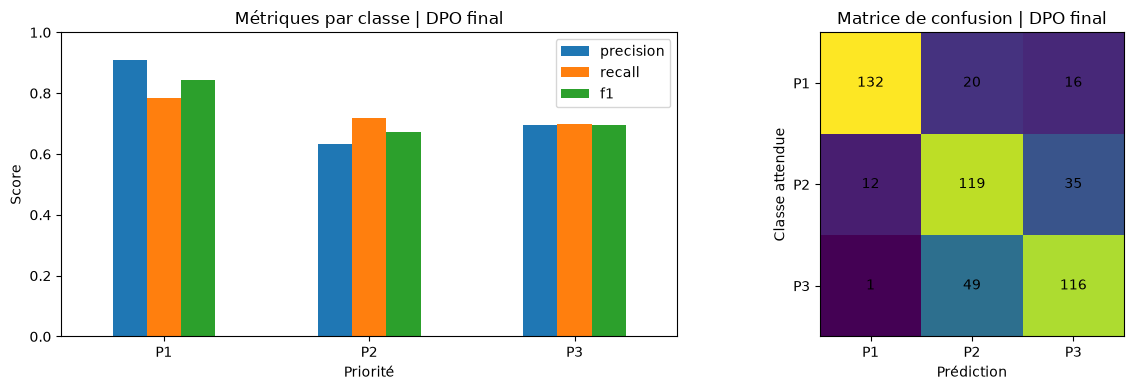

DPO preferences:   0%|          | 0/84 [00:00<?, ?pair/s]

In [31]:
# Évalue le DPO final sur exactement le même test figé que le SFT.
# Cette évaluation mesure la capacité de triage P1/P2/P3 après le DPO.

DPO_STAGE = "DPO final"


# Prédit P1/P2/P3 sur le test final conservé hors entraînement.
# L'utilisation du même test_df permet une comparaison directe SFT vs DPO.
dpo_results_df = score_priorities(
    model,
    tokenizer,
    test_df
)                                                                       # Prédictions P1/P2/P3

# Calcule les métriques globales, par classe et la matrice de confusion.
# Permet notamment de mesurer F1 macro et recall P1/P2/P3 après DPO.
dpo_metrics, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    stage=DPO_STAGE
)                                                                       # Métriques métier

# Mesure le taux de sous-triage et conserve les dossiers concernés.
# Ces détails permettent ensuite d'auditer individuellement les erreurs critiques.
dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    stage=DPO_STAGE
)                                                                       # Sous-triage

# Génère la visualisation des performances par classe et de la confusion.
dpo_figure = display_evaluation(
    dpo_class_metrics,
    dpo_confusion,
    DPO_STAGE
)                                                                       # Matrice de confusion


# ## Évaluation des préférences DPO

# Vérifie sur la validation DPO si le modèle attribue un meilleur score
# aux réponses chosen qu'aux réponses rejected correspondantes.
dpo_preference_results = score_dpo_preferences(
    model,
    tokenizer,
    validation_df,
)                                                                       # Chosen vs rejected

In [32]:
# Agrège les résultats de préférence : accuracy et marge moyenne de log-probabilité.
# Ces métriques évaluent la préférence DPO, pas directement le triage P1/P2/P3.
dpo_preference_metrics = evaluate_dpo_preferences(
    dpo_preference_results
)                                                                       # Métriques de préférence


# ## Affichage

# Présente séparément les performances métier, les préférences DPO et le sous-triage.
display(pd.DataFrame([dpo_metrics]))                                     # Triage P1/P2/P3
display(pd.DataFrame([dpo_preference_metrics]))                          # Préférences chosen/rejected
display(dpo_undertriage)                                                 # Sécurité : sous-triage


# ## Sauvegarde

# Sauvegarde la matrice de confusion pour le rapport et la comparaison SFT/DPO.
dpo_figure.savefig(
    RUN_METRIC_DIR / "dpo_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

# Sauvegarde toutes les prédictions du test final pour permettre leur audit.
save_predictions(
    RUN_METRIC_DIR / "dpo_predictions.jsonl",
    dpo_results_df
)

# Sauvegarde le score chosen/rejected et la marge de chaque paire DPO.
save_predictions(
    RUN_METRIC_DIR / "dpo_preference_predictions.jsonl",
    dpo_preference_results
)

# Sauvegarde uniquement les dossiers identifiés comme sous-triés.
save_predictions(
    RUN_METRIC_DIR / "dpo_undertriage_details.jsonl",
    dpo_undertriage_details
)

# Sauvegarde les métriques métier globales du DPO final.
save_metrics(
    RUN_METRIC_DIR / "dpo_metrics.json",
    dpo_metrics
)

# Sauvegarde séparément les métriques de préférence chosen/rejected.
save_metrics(
    RUN_METRIC_DIR / "dpo_preference_metrics.json",
    dpo_preference_metrics
)

plt.close(dpo_figure)                                                    # Libère la figure après sauvegarde.


# Résume les deux dimensions du benchmark final :
# performance de triage sur test_df et apprentissage des préférences sur la validation DPO.
print(
    f"✓ Benchmark DPO final sauvegardé\n"
    f"  Test triage     : {len(dpo_results_df):,}\n"
    f"  Paires DPO      : {len(dpo_preference_results):,}\n"
    f"  Preference acc. : "
    f"{dpo_preference_metrics['preference_accuracy']:.2%}\n"
    f"  LogP margin     : "
    f"{dpo_preference_metrics['preference_logp_margin']:+.4f}"
)

,stage,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,undertriage_rate,accuracy_en,f1_macro_en,accuracy_fr,f1_macro_fr
0,DPO final,500,0.734,0.745978,0.733792,0.737488,0.737912,0.142,0.68,0.683518,0.788,0.79076


,preference_accuracy,preference_logp_margin,preference_accuracy_p1,preference_logp_margin_p1,preference_accuracy_p2,preference_logp_margin_p2,preference_accuracy_p3,preference_logp_margin_p3
0,0.892857,1.398885,0.892857,1.336722,0.928571,1.507407,0.857143,1.352528


,stage,transition,count,support,rate_pct
0,DPO final,P1 → P2,20,168,11.904762
1,DPO final,P1 → P3,16,168,9.523810
2,DPO final,P2 → P3,35,166,21.084337


✓ Benchmark DPO final sauvegardé
  Test triage     : 500
  Paires DPO      : 84
  Preference acc. : 89.29%
  LogP margin     : +1.3989


In [33]:
# Journalise le benchmark DPO final dans un run W&B séparé.
# Ce run est dédié à l'évaluation finale et reste distinct du run d'entraînement DPO.

dpo_test_run = start_wandb_run("dpo-test", {

    # Taille du test figé et méthode utilisée pour prédire P1/P2/P3.
    "test_rows": len(dpo_results_df),
    "inference_method": "conditional_priority_scoring",

    # Traçabilité du modèle SFT à l'origine de la policy DPO.
    "sft_source_stamp": SFT_SOURCE_STAMP,
    "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,

    # Hyperparamètres principaux du DPO ayant produit l'adapter évalué.
    "dpo_beta": CONFIG.dpo_beta,
    "dpo_learning_rate": CONFIG.dpo_learning_rate,
    "dpo_epochs": CONFIG.dpo_epochs,

    # Empreintes des splits SFT pour garantir que le benchmark reste reproductible.
    "train_sha256": file_sha256(SFT_TRAIN_PATH),
    "validation_sha256": file_sha256(SFT_VALIDATION_PATH),
    "test_sha256": file_sha256(SFT_TEST_PATH),

    # Seed globale utilisée pour rendre l'expérience reproductible.
    "seed": CONFIG.seed
})


# Journalise uniquement si W&B est activé et qu'un run a bien été créé.
if dpo_test_run:
    try:

        # Conserve uniquement les métriques numériques compatibles avec W&B.
        # Les scalaires NumPy sont convertis en types Python standards.
        numeric_metrics = {
            f"test/{key}": value.item() if hasattr(value, "item") else value
            for key, value in dpo_metrics.items()
            if isinstance(value, (int, float, np.integer, np.floating))
        }

        # Envoie les métriques et les principaux artefacts du benchmark final.
        dpo_test_run.log({
            **numeric_metrics,                                           # Accuracy, F1, recall, undertriage...
            "test/predictions": wandb.Table(dataframe=dpo_results_df),   # Prédictions individuelles.
            "test/undertriage": wandb.Table(dataframe=dpo_undertriage),  # Synthèse du sous-triage.
            "test/confusion_matrix": wandb.Image(                        # Matrice de confusion sauvegardée.
                str(RUN_METRIC_DIR / "dpo_confusion_matrix.png")
            )
        })

    finally:
        dpo_test_run.finish()  # Ferme proprement le run même en cas d'erreur W&B.


# Confirme la fin de la journalisation du benchmark final.
print("✓ Benchmark DPO journalisé dans W&B")

test/accuracy,▁
test/accuracy_en,▁
test/accuracy_fr,▁
test/f1_macro,▁
test/f1_macro_en,▁
test/f1_macro_fr,▁
test/f1_weighted,▁
test/precision_macro,▁
test/recall_macro,▁
test/rows,▁
+1,...


✓ Benchmark DPO journalisé dans W&B


In [34]:
# Génère librement la réponse complète du modèle sur un cas clinique.
# Vérifie également que Qwen3 termine correctement sa réponse avec <|im_end|>.
def generate_test(model, tokenizer, row, max_new_tokens=256):
    """Génère priorité + explication et contrôle la terminaison."""

    # Construit exactement le même échange système + patient que pour l'évaluation.
    messages = [
        {"role": "system", "content": system_prompt(row["language"])},  # Instructions FR/EN.
        {"role": "user", "content": clinical_input(row)}               # Cas clinique.
    ]

    # Applique le chat template natif de Qwen3 sans tokeniser immédiatement.
    # Le thinking est désactivé pour obtenir directement PRIORITY + EXPLANATION.
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,  # Ajoute le début du tour assistant.
        enable_thinking=False        # Désactive le mode raisonnement de Qwen3.
    )

    # Tokenise le prompt déjà formaté par le chat template.
    # Aucun token spécial supplémentaire n'est ajouté pour éviter les doublons.
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False
    ).to(model.device)

    # Récupère l'identifiant du marqueur de fin d'un message Qwen3.
    im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")

    # Génération déterministe sans calcul de gradient.
    # La génération s'arrête dès que <|im_end|> est produit ou à la limite de tokens.
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,          # Limite de la réponse générée.
            do_sample=False,                        # Génération déterministe.
            eos_token_id=im_end_id,                 # Arrêt explicite sur <|im_end|>.
            pad_token_id=tokenizer.pad_token_id     # Padding défini pour Qwen3.
        )

    # Retire les tokens du prompt pour ne conserver que la réponse du modèle.
    generated_ids = output[
        0,
        inputs["input_ids"].shape[1]:
    ].tolist()

    # Vérifie si le modèle a produit explicitement son token de fin.
    ended = im_end_id in generated_ids

    # Retourne le texte et les informations permettant d'auditer la terminaison.
    return {
        "text": tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip(),
        "ended": ended,                    # True si <|im_end|> a été généré.
        "tokens": len(generated_ids),       # Nombre total de tokens générés.
        "im_end_position": (
            generated_ids.index(im_end_id) # Position du token de terminaison.
            if ended
            else None                      # None si arrêt par max_new_tokens.
        )
    }

In [35]:
# Test qualitatif équilibré du DPO sur 9 cas du test figé.
# Sélectionne 3 cas P1, 3 P2 et 3 P3 pour contrôler la génération réelle du modèle.

sample = pd.concat([
    test_df.loc[test_df["priority"].eq(priority)]
    .sample(3, random_state=CONFIG.seed + priority)  # Échantillon reproductible par classe.
    for priority in (1, 2, 3)
]).reset_index(drop=True)


# Stocke les générations et leurs informations de contrôle.
dpo_generation_results = []


# Génère une réponse complète pour chacun des 9 cas sélectionnés.
# Ce test qualitatif complète le benchmark quantitatif réalisé sur tout test_df.
for _, row in sample.iterrows():
    result = generate_test(
        model,
        tokenizer,
        row,
        max_new_tokens=512  # Laisse suffisamment d'espace pour priorité + explication.
    )

    # Conserve le cas source, la priorité attendue et la génération obtenue.
    # Les informations de terminaison sont ajoutées via le dictionnaire result.
    dpo_generation_results.append({
        "id": row["id"],
        "expected": int(row["priority"]),       # Priorité de référence.
        "language": row["language"],            # Langue FR/EN du cas.
        "model_context": row["model_context"],  # Contexte clinique fourni au modèle.
        **result                                # Texte, terminaison et nombre de tokens.
    })

    # Affiche chaque génération pour permettre une inspection qualitative immédiate.
    print("=" * 90)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['priority']}")
    print(f"LANGUE   : {row['language']}")
    print(
        f"FIN      : "
        f"{'✓ <|im_end|>' if result['ended'] else '✗ ABSENT'}"
    )
    print(f"TOKENS   : {result['tokens']}")
    print()
    print(result["text"])


# Regroupe les 9 générations dans un DataFrame pour analyse ou sauvegarde ultérieure.
dpo_generation_df = pd.DataFrame(dpo_generation_results)


# Vérifie que les 9 cas attendus ont bien été générés.
print(f"\n✓ Générations DPO : {len(dpo_generation_df)}")

Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 40

PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : bb9ce92508d636f07f600c3f
ATTENDU  : P1
LANGUE   : fr
FIN      : ✓ <|im_end|>
TOKENS   : 54

PRIORITY: P1
EXPLANATION: Priorité P1 : retractions. Le dossier rapporte aussi 80.0, 100.0. Ces éléments cliniques documentés justifient une prise en charge immédiate.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

ID       : 9d82dc3958346a13a68c1cf8
ATTENDU  : P2
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 90

PRIORITY: P2
EXPLANATION: Priority P2: the presentation includes The patient has Neuroacanthocytosis. The patient presents with cardiac problems and movement disorders and acanthocytosis (abnormal, spiculated red blood cells), together with movement disorders and acanthocytosis (abnormal, spiculated red blood cells), Neuroacanthocytosis. These patient-specific findings support prompt assessment.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 50c7812a1087d137360b307e
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 75

PRIORITY: P3
EXPLANATION: Priority P3: Symptoms of PKD include - Pain in the back and lower sides - Headaches - Urinary tract infections - Blood in the urine Doctors diagnose PKD with imaging tests and family history. The case also documents (are) Kidney Cysts, kidney failure. These documented clinical findings support deferred care.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : b04e786dd80d07dfcd4fd01c
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 96

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, an increased risk of age-related macular degeneration. Other triage-relevant findings are age-related macular degeneration risk, or whether increased risk results from variations in both genes, age-related macular degeneration include genes involved in transporting and processing high-density lipoprotein (HDL, also known as "good" cholesterol) and gene. The documented presentation supports prompt assessment.
ID       : 1f8dff51475ea47856bb3b68
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 72

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, bronchopulmonary dysplasia (BPD). Other triage-relevant findings are BPD, doctors may recommend tests, such as, takes pictures of the structures inside the chest, such as the heart and lungs. The documented presentation supports prompt assessment.

✓ Générations DPO : 9

In [36]:
# Compare la cible SFT et la génération DPO réelle sur les 9 cas.
# Permet une inspection qualitative contexte → cible attendue → réponse du modèle.

# Ajoute à chaque génération DPO l'explication cible présente dans le test SFT.
# La jointure par ID garantit que chaque génération est comparée à sa référence.
dpo_generation_audit_df = dpo_generation_df.merge(
    test_df[["id", "explanation"]],
    on="id",
    how="left"
)


# Affiche chaque cas complet pour permettre une comparaison qualitative manuelle.
# L'objectif est d'observer la fidélité clinique, le format et la qualité de l'explication.
for _, row in dpo_generation_audit_df.iterrows():
    print("=" * 100)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['expected']}")  # Priorité de référence du test figé.
    print(f"LANGUE   : {row['language']}")
    print()

    # Contexte clinique réellement présenté au modèle.
    print("CONTEXTE")
    print("-" * 100)
    print(row["model_context"])
    print()

    # Explication cible issue du dataset SFT.
    # Elle sert de référence qualitative, sans imposer une reproduction mot à mot.
    print("EXPLICATION CIBLE SFT")
    print("-" * 100)
    print(row["explanation"])
    print()

    # Réponse réellement générée par le modèle après entraînement DPO.
    # Permet de vérifier priorité, pertinence, langue et qualité rédactionnelle.
    print("GÉNÉRATION DPO")
    print("-" * 100)
    print(row["text"])
    print()

ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en

CONTEXTE
----------------------------------------------------------------------------------------------------
Contexte médical:
The patient has (are) Drug Reactions. Clinical manifestations explicitly associated with the condition include But medicines can also cause unwanted reactions.

Informations patient:
condition_mentions: ["(are) Drug Reactions"]

Informations médicales:
medications: ["the drug"]
pathogens: ["the drugs"]
anatomy: ["skin", "stomach"]

EXPLICATION CIBLE SFT
----------------------------------------------------------------------------------------------------
Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.

GÉNÉRATION DPO
----------------------------------------------------------------------------------------------------
PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug,

In [37]:
# Résume la qualité structurelle des générations DPO.

dpo_generation_df = pd.DataFrame(dpo_generation_results)

dpo_generation_df["has_priority"] = (
    dpo_generation_df["text"]
    .str.match(r"^PRIORITY: P[123]")
)

dpo_generation_df["has_explanation"] = (
    dpo_generation_df["text"]
    .str.contains(r"\nEXPLANATION:\s*\S", regex=True)
)

display(
    dpo_generation_df[
        [
            "id",
            "expected",
            "language",
            "ended",
            "tokens",
            "has_priority",
            "has_explanation"
        ]
    ]
)

print(
    f"Terminaison <|im_end|> : "
    f"{dpo_generation_df['ended'].sum()}/{len(dpo_generation_df)} "
    f"({dpo_generation_df['ended'].mean() * 100:.1f} %)"
)

print(
    f"Format PRIORITY        : "
    f"{dpo_generation_df['has_priority'].mean() * 100:.1f} %"
)

print(
    f"Format EXPLANATION     : "
    f"{dpo_generation_df['has_explanation'].mean() * 100:.1f} %"
)

,id,expected,language,ended,tokens,has_priority,has_explanation
0,56988ee1630ead95b6281fdc,1,en,True,40,True,True
1,bb9ce92508d636f07f600c3f,1,fr,True,54,True,True
2,1cca922f4dab2d0005389ee3,1,fr,True,61,True,True
3,489404d1e35d85649304a4e0,2,en,True,54,True,True
4,fb3425033d3781d64259771a,2,en,True,60,True,True
5,9d82dc3958346a13a68c1cf8,2,en,True,90,True,True
6,50c7812a1087d137360b307e,3,en,True,75,True,True
7,b04e786dd80d07dfcd4fd01c,3,en,True,96,True,True
8,1f8dff51475ea47856bb3b68,3,en,True,72,True,True


Terminaison <|im_end|> : 9/9 (100.0 %)
Format PRIORITY        : 100.0 %
Format EXPLANATION     : 100.0 %


In [38]:
# Libération mémoire DPO
# Supprime les objets lourds du DPO avant la validation croisée.

for name in (
    "dpo_trainer",
    "model",
    "dpo_train_output",
):
    globals().pop(name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    free, total = torch.cuda.mem_get_info()

    print(
        f"✓ GPU libéré | "
        f"{free / 1024**3:.2f}/{total / 1024**3:.2f} Go disponibles"
    )

✓ GPU libéré | 3.58/6.00 Go disponibles


In [39]:
# Contrôle l'état mémoire après la cross-validation.
# Distingue RAM, VRAM active, cache PyTorch et mémoire GPU libre.

import gc
import psutil
import torch

gc.collect()

gb = 1024**3
ram = psutil.virtual_memory()

print(
    f"RAM  | utilisée={ram.used / gb:.2f} Go | "
    f"disponible={ram.available / gb:.2f} Go | "
    f"total={ram.total / gb:.2f} Go | {ram.percent:.1f}%"
)

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()

    print(
        f"CUDA | allouée={torch.cuda.memory_allocated() / gb:.2f} Go | "
        f"réservée={torch.cuda.memory_reserved() / gb:.2f} Go | "
        f"pic={torch.cuda.max_memory_allocated() / gb:.2f} Go | "
        f"libre={free / gb:.2f}/{total / gb:.2f} Go"
    )

    print(
        f"GPU  | {torch.cuda.get_device_name(0)} | "
        f"CUDA={torch.version.cuda}"
    )
else:
    print("CUDA | indisponible")

RAM  | utilisée=12.92 Go | disponible=10.79 Go | total=23.71 Go | 54.5%
CUDA | allouée=0.62 Go | réservée=1.32 Go | pic=6.04 Go | libre=3.58/6.00 Go
GPU  | NVIDIA GeForce RTX 4050 Laptop GPU | CUDA=13.0


11. Comparaison SFT/DPO

Je mesure les deltas globaux et par priorité, puis j’effectue un test de McNemar exact sur les succès appariés. Un DPO n’est considéré utile que si son amélioration est visible sur le test figé, notamment sur le rappel P1.


In [40]:
# Recharge les prédictions SFT et DPO du même test figé.

prediction_paths = {
    "SFT": RUN_METRIC_DIR / "sft_predictions.jsonl",
    "DPO": RUN_METRIC_DIR / "dpo_predictions.jsonl"
}

results = {}

for stage, path in prediction_paths.items():
    if not path.is_file():
        raise FileNotFoundError(
            f"Prédictions {stage} introuvables : {path}"
        )

    df = pd.DataFrame(read_jsonl(path))

    assert len(df) == len(test_df), (
        f"{stage}: {len(df)} prédictions pour {len(test_df)} cas attendus."
    )

    assert df["id"].is_unique, (
        f"{stage}: identifiants dupliqués."
    )

    results[stage] = df


sft_results_df = results["SFT"]
dpo_results_df = results["DPO"]


# Vérifie que SFT et DPO portent exactement sur les mêmes patients.

assert set(sft_results_df["id"]) == set(dpo_results_df["id"]), (
    "SFT et DPO n'ont pas exactement les mêmes IDs."
)

assert set(sft_results_df["id"]) == set(test_df["id"]), (
    "Les prédictions ne correspondent pas exactement au test figé."
)


print(
    f"✓ SFT : {len(sft_results_df)} cas | "
    f"DPO : {len(dpo_results_df)} cas | "
    f"Test figé : {len(test_df)} cas"
)

display(sft_results_df.head())
display(dpo_results_df.head())

✓ SFT : 500 cas | DPO : 500 cas | Test figé : 500 cas


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.340621,-0.090621,-0.340621
1,e6876f343414ec76ae980763,en,3,3,PRIORITY: P3,-0.638035,-0.188035,-0.113035
2,a97dfcfe721621b900f12b31,fr,2,2,PRIORITY: P2,-0.767033,-0.067033,-0.267033
3,89c1e758195b94ea6d1f5bf7,fr,3,3,PRIORITY: P3,-1.380464,-0.730464,-0.005464
4,9b62ae1658ac22fed26a7aef,fr,3,3,PRIORITY: P3,-1.082636,-0.682636,-0.007636


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.361292,-0.086292,-0.336292
1,e6876f343414ec76ae980763,en,3,3,PRIORITY: P3,-0.686206,-0.186206,-0.111206
2,a97dfcfe721621b900f12b31,fr,2,2,PRIORITY: P2,-0.774304,-0.049305,-0.324305
3,89c1e758195b94ea6d1f5bf7,fr,3,3,PRIORITY: P3,-1.356958,-0.681958,-0.006958
4,9b62ae1658ac22fed26a7aef,fr,3,3,PRIORITY: P3,-1.083511,-0.658511,-0.008511


In [41]:
# Recharge les métriques et prédictions SFT / DPO du test figé.

with (RUN_METRIC_DIR / "sft_metrics.json").open(encoding="utf-8") as file:
    sft_metrics = json.load(file)

with (RUN_METRIC_DIR / "dpo_metrics.json").open(encoding="utf-8") as file:
    dpo_metrics = json.load(file)

sft_results_df = pd.read_json(
    RUN_METRIC_DIR / "sft_predictions.jsonl",
    lines=True
)

dpo_results_df = pd.read_json(
    RUN_METRIC_DIR / "dpo_predictions.jsonl",
    lines=True
)

# Contrôles du benchmark apparié.
assert len(sft_results_df) == len(test_df)
assert len(dpo_results_df) == len(test_df)

assert sft_results_df["id"].is_unique
assert dpo_results_df["id"].is_unique

assert set(sft_results_df["id"]) == set(dpo_results_df["id"])
assert set(sft_results_df["id"]) == set(test_df["id"])

print(
    f"✓ Résultats rechargés | "
    f"SFT={len(sft_results_df):,} | "
    f"DPO={len(dpo_results_df):,} | "
    f"Test={len(test_df):,}"
)

✓ Résultats rechargés | SFT=500 | DPO=500 | Test=500


In [42]:
# Reconstruit les métriques par classe depuis les prédictions sauvegardées.

_, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    stage="SFT final"
)

_, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    stage="DPO final"
)

print("✓ Métriques par classe SFT / DPO reconstruites")

✓ Métriques par classe SFT / DPO reconstruites


In [43]:
# Construit la comparaison finale SFT / DPO.

sft_comparison = comparison_metrics(
    sft_metrics,
    sft_class_metrics
)

dpo_comparison = comparison_metrics(
    dpo_metrics,
    dpo_class_metrics
)

comparison_keys = list(sft_comparison)

metrics_comparison_df = pd.DataFrame({
    "metric": comparison_keys,
    "SFT final": [
        sft_comparison[key]
        for key in comparison_keys
    ],
    "DPO final": [
        dpo_comparison[key]
        for key in comparison_keys
    ]
})

metrics_comparison_df["delta"] = (
    metrics_comparison_df["DPO final"]
    - metrics_comparison_df["SFT final"]
)

display(metrics_comparison_df)

,metric,SFT final,DPO final,delta
0,accuracy,0.744000,0.734000,-0.010000
1,precision_macro,0.754476,0.745978,-0.008498
2,recall_macro,0.743832,0.733792,-0.010040
3,f1_macro,0.747071,0.737488,-0.009583
4,f1_weighted,0.747456,0.737912,-0.009545
5,undertriage_rate,0.144000,0.142000,-0.002000
6,precision_p1,0.910345,0.910345,0.000000
7,recall_p1,0.785714,0.785714,0.000000
8,f1_p1,0.843450,0.843450,0.000000
9,precision_p2,0.651934,0.632979,-0.018955


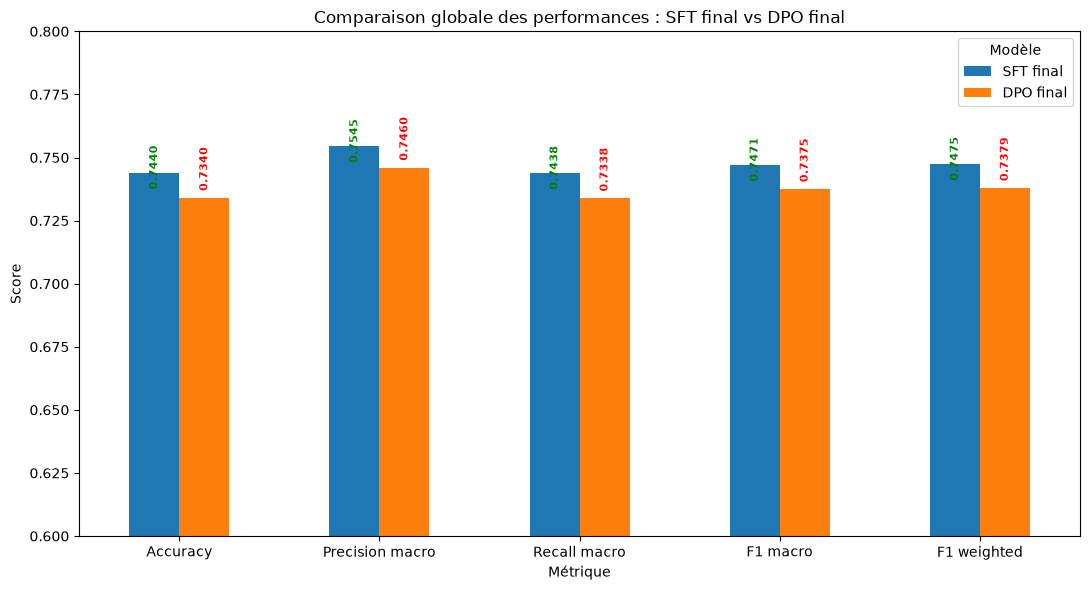

In [44]:
# Visualise les métriques globales SFT final et DPO final.

global_metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]

global_metrics_df = (
    metrics_comparison_df
    .set_index("metric")
    .loc[global_metrics, ["SFT final", "DPO final"]]
)

global_metrics_df.index = [
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro",
    "F1 weighted"
]

ax = global_metrics_df.plot.bar(figsize=(11, 6))

ax.set(
    ylim=(0.60, 0.80),
    xlabel="Métrique",
    ylabel="Score",
    title="Comparaison globale des performances : SFT final vs DPO final"
)

ax.tick_params(axis="x", rotation=0)
ax.legend(title="Modèle")


# Colore les valeurs : meilleur en vert, moins bon en rouge, égalité en noir.

values = global_metrics_df[["SFT final", "DPO final"]].to_numpy()

for model_index, container in enumerate(ax.containers):
    offset = -12 if model_index == 0 else 5

    for metric_index, bar in enumerate(container):
        value = bar.get_height()
        other = values[metric_index, 1 - model_index]

        if np.isclose(value, other):
            color = "black"
        elif value > other:
            color = "green"
        else:
            color = "red"

        ax.annotate(
            f"{value:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()

figure = ax.get_figure()

figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_global_metrics_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Construit les métriques P1/P2/P3 pour le graphique.

rows = []

for priority in (1, 2, 3):
    for metric in ("precision", "recall", "f1"):
        key = f"{metric}_p{priority}"

        rows.append({
            "label": f"P{priority} {metric.title()}",
            "SFT final": sft_comparison[key],
            "DPO final": dpo_comparison[key]
        })

class_metrics_df = pd.DataFrame(rows)

display(class_metrics_df.round(6))

,label,SFT final,DPO final
0,P1 Precision,0.910345,0.910345
1,P1 Recall,0.785714,0.785714
2,P1 F1,0.843450,0.843450
3,P2 Precision,0.651934,0.632979
4,P2 Recall,0.710843,0.716867
5,P2 F1,0.680115,0.672316
6,P3 Precision,0.701149,0.694611
7,P3 Recall,0.734940,0.698795
8,P3 F1,0.717647,0.696697


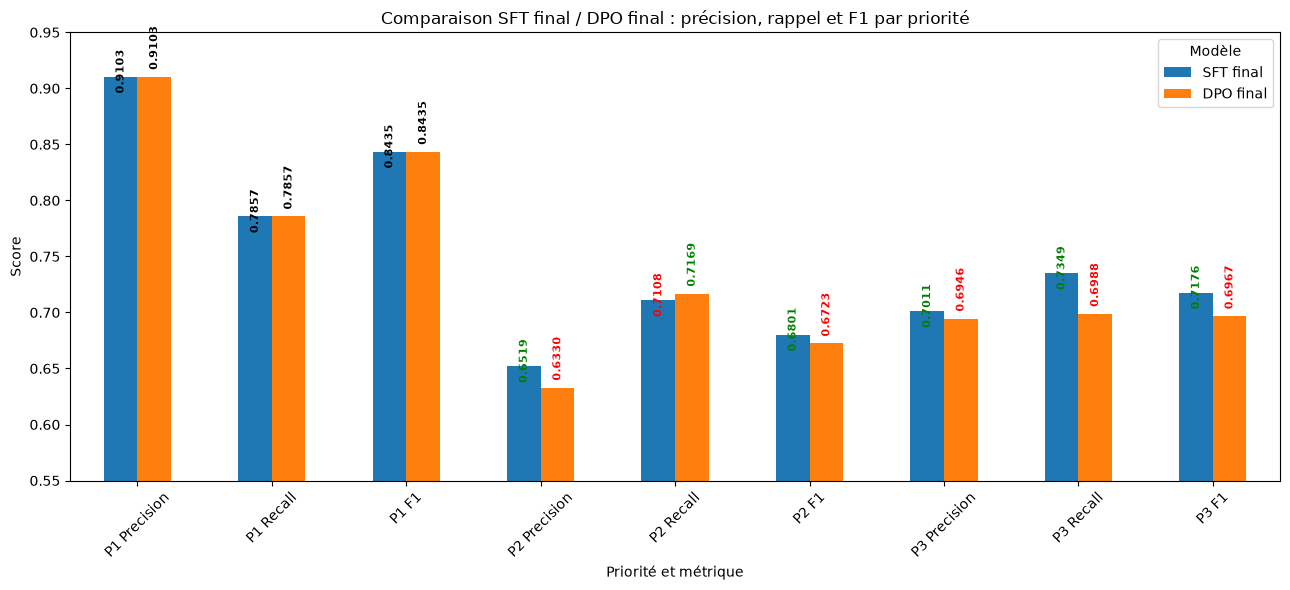

In [48]:
# Visualise les performances par priorité.

plot_df = class_metrics_df.set_index("label")[
    ["SFT final", "DPO final"]
]

ax = plot_df.plot.bar(figsize=(13, 6))

ax.set(
    ylim=(0.55, 0.95),
    xlabel="Priorité et métrique",
    ylabel="Score",
    title="Comparaison SFT final / DPO final : précision, rappel et F1 par priorité"
)

ax.tick_params(axis="x", rotation=45)
ax.legend(title="Modèle")


# Colore les valeurs : meilleur en vert, moins bon en rouge, égalité en noir.

values = plot_df.to_numpy()

for model_index, container in enumerate(ax.containers):
    offset = -12 if model_index == 0 else 5

    for metric_index, bar in enumerate(container):
        value = bar.get_height()
        other = values[metric_index, 1 - model_index]

        if np.isclose(value, other):
            color = "black"
        elif value > other:
            color = "green"
        else:
            color = "red"

        ax.annotate(
            f"{value:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()

figure = ax.get_figure()

figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_class_metrics_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Recalcule le sous-triage depuis les prédictions sauvegardées.

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    "SFT final"
)

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    "DPO final"
)

print("✓ Sous-triage SFT / DPO recalculé")

✓ Sous-triage SFT / DPO recalculé


In [50]:
# Compare le sous-triage SFT final et DPO final.
# Delta négatif = amélioration, delta positif = dégradation.

undertriage_comparison = sft_undertriage[
    ["transition", "count", "rate_pct"]
].merge(
    dpo_undertriage[["transition", "count", "rate_pct"]],
    on="transition",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

undertriage_comparison["count_delta"] = (
    undertriage_comparison["count_dpo"]
    - undertriage_comparison["count_sft"]
)

undertriage_comparison["rate_delta"] = (
    undertriage_comparison["rate_pct_dpo"]
    - undertriage_comparison["rate_pct_sft"]
).round(2)


# Affichage lisible pour l'analyse.

undertriage_display = undertriage_comparison.rename(columns={
    "transition": "Sous-triage",
    "count_sft": "Cas SFT",
    "rate_pct_sft": "Taux SFT (%)",
    "count_dpo": "Cas DPO",
    "rate_pct_dpo": "Taux DPO (%)",
    "count_delta": "Δ cas",
    "rate_delta": "Δ taux (pts)"
})

print("=== SOUS-TRIAGE : SFT final vs DPO final ===")
print("Δ négatif = réduction du sous-triage | Δ positif = augmentation")

display(
    undertriage_display.style.format({
        "Taux SFT (%)": "{:.2f}%",
        "Taux DPO (%)": "{:.2f}%",
        "Δ taux (pts)": "{:+.2f}"
    })
)


# Sauvegarde les valeurs techniques.

undertriage_comparison.to_csv(
    RUN_METRIC_DIR / "sft_dpo_undertriage_comparison.csv",
    index=False,
    encoding="utf-8"
)

=== SOUS-TRIAGE : SFT final vs DPO final ===
Δ négatif = réduction du sous-triage | Δ positif = augmentation


,Sous-triage,Cas SFT,Taux SFT (%),Cas DPO,Taux DPO (%),Δ cas,Δ taux (pts)
0,P1 → P2,20,11.90%,20,11.90%,0,+0.00
1,P1 → P3,16,9.52%,16,9.52%,0,+0.00
2,P2 → P3,36,21.69%,35,21.08%,-1,-0.60


In [51]:


# Compare les succès SFT et DPO avec le test exact de McNemar.

paired = sft_results_df[
    ["id", "expected", "predicted"]
].merge(
    dpo_results_df[["id", "expected", "predicted"]],
    on="id",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

# Vérifie que la comparaison porte exactement sur le test gelé.
assert len(paired) == len(test_df)
assert paired["id"].is_unique
assert (paired["expected_sft"] == paired["expected_dpo"]).all()

paired["expected"] = paired["expected_sft"]

paired["sft_correct"] = (
    paired["expected"] == paired["predicted_sft"]
)

paired["dpo_correct"] = (
    paired["expected"] == paired["predicted_dpo"]
)

sft_only = int(
    (paired["sft_correct"] & ~paired["dpo_correct"]).sum()
)

dpo_only = int(
    (~paired["sft_correct"] & paired["dpo_correct"]).sum()
)

both_correct = int(
    (paired["sft_correct"] & paired["dpo_correct"]).sum()
)

both_wrong = int(
    (~paired["sft_correct"] & ~paired["dpo_correct"]).sum()
)

discordant = sft_only + dpo_only

mcnemar_pvalue = (
    binomtest(
        dpo_only,
        discordant,
        p=0.5
    ).pvalue
    if discordant
    else 1.0
)


# Tableau 1 : transitions de classes SFT → DPO.

transition_table = pd.crosstab(
    paired["predicted_sft"],
    paired["predicted_dpo"],
    rownames=["Prédiction SFT"],
    colnames=["Prédiction DPO"],
    dropna=False
)

transition_table.index = [
    f"P{x}" for x in transition_table.index
]

transition_table.columns = [
    f"P{x}" for x in transition_table.columns
]

print("=== TRANSITIONS DE PRÉDICTIONS : SFT final → DPO final ===")
display(transition_table)


# Tableau 2 : évolution du statut correct / incorrect.

agreement_df = pd.DataFrame({
    "Résultat": [
        "Correct avec les deux modèles",
        "Incorrect avec les deux modèles",
        "Correct SFT → incorrect DPO",
        "Incorrect SFT → correct DPO"
    ],
    "Cas": [
        both_correct,
        both_wrong,
        sft_only,
        dpo_only
    ]
})

agreement_df["Part (%)"] = (
    agreement_df["Cas"] / len(paired) * 100
)

print("=== COMPARAISON DES SUCCÈS SFT / DPO ===")

display(
    agreement_df.style.format({
        "Part (%)": "{:.2f}%"
    })
)


# Tableau 3 : test exact de McNemar.

mcnemar_df = pd.DataFrame({
    "Indicateur": [
        "Cas testés",
        "SFT seul correct",
        "DPO seul correct",
        "Paires discordantes",
        "McNemar p-value"
    ],
    "Valeur": [
        len(paired),
        sft_only,
        dpo_only,
        discordant,
        mcnemar_pvalue
    ]
})

print("=== TEST EXACT DE McNEMAR ===")
display(mcnemar_df)


# Sauvegarde les résultats.

transition_table.to_csv(
    RUN_METRIC_DIR / "sft_dpo_prediction_transitions.csv",
    encoding="utf-8"
)

mcnemar_results = {
    "test_rows": len(paired),
    "both_correct": both_correct,
    "both_wrong": both_wrong,
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "discordant": discordant,
    "p_value": float(mcnemar_pvalue)
}

(RUN_METRIC_DIR / "sft_dpo_mcnemar.json").write_text(
    json.dumps(mcnemar_results, indent=2),
    encoding="utf-8"
)

print("✓ Comparaison appariée SFT / DPO sauvegardée")

=== TRANSITIONS DE PRÉDICTIONS : SFT final → DPO final ===


,P1,P2,P3
P1,144,1,0
P2,1,179,1
P3,0,8,166


=== COMPARAISON DES SUCCÈS SFT / DPO ===


,Résultat,Cas,Part (%)
0,Correct avec les deux modèles,364,72.80%
1,Incorrect avec les deux modèles,125,25.00%
2,Correct SFT → incorrect DPO,8,1.60%
3,Incorrect SFT → correct DPO,3,0.60%


=== TEST EXACT DE McNEMAR ===


,Indicateur,Valeur
0,Cas testés,500.000000
1,SFT seul correct,8.000000
2,DPO seul correct,3.000000
3,Paires discordantes,11.000000
4,McNemar p-value,0.226562


✓ Comparaison appariée SFT / DPO sauvegardée


In [52]:
# Résume factuellement l'effet du DPO sur le test commun.

macro_delta = (
    dpo_comparison["f1_macro"]
    - sft_comparison["f1_macro"]
)

p1_recall_delta = (
    dpo_comparison["recall_p1"]
    - sft_comparison["recall_p1"]
)

if macro_delta > 0 and p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1 et le rappel P1 "
        "sur le test commun."
    )
elif p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le rappel P1, tandis que le macro-F1 "
        "n'augmente pas."
    )
elif macro_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1, tandis que le rappel P1 "
        "n'augmente pas."
    )
else:
    conclusion = (
        "Le DPO n'augmente ni le macro-F1 ni le rappel P1 "
        "sur le test commun."
    )

comparison_payload = {
    "macro_f1_delta": float(macro_delta),
    "p1_recall_delta": float(p1_recall_delta),
    "mcnemar_pvalue": float(mcnemar_pvalue),
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "conclusion": conclusion
}

(RUN_METRIC_DIR / "sft_dpo_conclusion.json").write_text(
    json.dumps(
        comparison_payload,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

display(pd.DataFrame([comparison_payload]))

print(conclusion)
print(
    "Conclusion à compléter par la matrice de confusion, "
    "le sous-triage et l'analyse des erreurs."
)
print("✓ Comparaison SFT / DPO terminée")

,macro_f1_delta,p1_recall_delta,mcnemar_pvalue,sft_only_correct,dpo_only_correct,conclusion
0,-0.009583,0.0,0.226562,8,3,Le DPO n'augmente ni le macro-F1 ni le rappel ...


Le DPO n'augmente ni le macro-F1 ni le rappel P1 sur le test commun.
Conclusion à compléter par la matrice de confusion, le sous-triage et l'analyse des erreurs.
✓ Comparaison SFT / DPO terminée


## 12. Conclusion et manifeste

Je termine en sauvegardant les versions, empreintes, chemins et métriques. Ce manifeste permet de relier un résultat aux données, aux adaptateurs et au groupe W&B qui l’ont produit.


In [53]:


# Construit le manifest final uniquement avec les variables réellement disponibles.

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),

    # Run
    "run": {
        "stamp": RUN_STAMP,
        "group": RUN_GROUP,
        "wandb_enabled": USE_WANDB,
        "wandb_project": WANDB_PROJECT if USE_WANDB else None,
        "seed": CONFIG.seed
    },

    # Configuration complète
    "configuration": asdict(CONFIG),

    # Environnement
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
        "gpu_count": (
            torch.cuda.device_count()
            if torch.cuda.is_available()
            else 0
        ),
        "bf16_supported": (
            torch.cuda.is_bf16_supported()
            if torch.cuda.is_available()
            else False
        )
    },

    # Provenance des modèles
    "models": {
        "base_model": "unsloth/Qwen3-1.7B-unsloth-bnb-4bit",
        "sft_source_stamp": SFT_SOURCE_STAMP,
        "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
        "dpo_adapter": str(DPO_MODEL_PATH)
    },

    # Jeu de test final
    "test": {
        "rows": len(test_df),
        "sft_prediction_rows": len(sft_results_df),
        "dpo_prediction_rows": len(dpo_results_df),
        "same_ids": (
            set(sft_results_df["id"])
            == set(dpo_results_df["id"])
            == set(test_df["id"])
        )
    },

    # Résultats SFT
    "sft_results": {
        "global_metrics": sft_metrics,

        "per_class_metrics": (
            sft_class_metrics.to_dict("records")
        ),

        "confusion_matrix": (
            np.asarray(sft_confusion).tolist()
        ),

        "undertriage": (
            sft_undertriage.to_dict("records")
        ),

        "undertriage_details_rows": len(
            sft_undertriage_details
        )
    },

    # Résultats DPO
    "dpo_results": {
        "global_metrics": dpo_metrics,

        "per_class_metrics": (
            dpo_class_metrics.to_dict("records")
        ),

        "confusion_matrix": (
            np.asarray(dpo_confusion).tolist()
        ),

        "undertriage": (
            dpo_undertriage.to_dict("records")
        ),

        "undertriage_details_rows": len(
            dpo_undertriage_details
        )
    },

    # Comparaison des métriques globales
    "global_comparison": (
        metrics_comparison_df.to_dict("records")
    ),

    # Comparaison par priorité
    "class_comparison": (
        class_metrics_df.to_dict("records")
    ),

    # Comparaison du sous-triage
    "undertriage_comparison": (
        undertriage_comparison.to_dict("records")
    ),

    # Comparaison appariée SFT / DPO
    "paired_comparison": {
        "test_rows": len(paired),

        "both_correct": both_correct,
        "both_wrong": both_wrong,

        "sft_only_correct": sft_only,
        "dpo_only_correct": dpo_only,

        "discordant": discordant,

        "mcnemar_exact": {
            "method": "exact_binomial",
            "alternative": "two-sided",
            "p_value": float(mcnemar_pvalue)
        },

        "prediction_transitions": (
            transition_table
            .reset_index()
            .to_dict("records")
        )
    },

    # Résultat McNemar sauvegardé
    "mcnemar": mcnemar_results,

    # Artefacts de l'évaluation finale
    "artifacts": {
        "sft_metrics": str(
            RUN_METRIC_DIR / "sft_metrics.json"
        ),

        "dpo_metrics": str(
            RUN_METRIC_DIR / "dpo_metrics.json"
        ),

        "sft_predictions": str(
            RUN_METRIC_DIR / "sft_predictions.jsonl"
        ),

        "dpo_predictions": str(
            RUN_METRIC_DIR / "dpo_predictions.jsonl"
        ),

        "global_metrics_figure": str(
            RUN_METRIC_DIR
            / "sft_dpo_global_metrics_comparison.png"
        ),

        "class_metrics_figure": str(
            RUN_METRIC_DIR
            / "sft_dpo_class_metrics_comparison.png"
        ),

        "undertriage_comparison": str(
            RUN_METRIC_DIR
            / "sft_dpo_undertriage_comparison.csv"
        ),

        "prediction_transitions": str(
            RUN_METRIC_DIR
            / "sft_dpo_prediction_transitions.csv"
        ),

        "mcnemar": str(
            RUN_METRIC_DIR
            / "sft_dpo_mcnemar.json"
        )
    }
}


# Sauvegarde.

MANIFEST_PATH = RUN_METRIC_DIR / "experiment_manifest.json"

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        ensure_ascii=False,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)


# Contrôles finaux.

assert manifest["test"]["rows"] == len(test_df)
assert manifest["test"]["same_ids"]
assert manifest["paired_comparison"]["test_rows"] == len(test_df)


# Résumé.

print("=== MANIFEST EXPÉRIMENTAL FINAL ===")
print(f"Run             : {RUN_STAMP}")
print(f"Groupe W&B      : {RUN_GROUP}")
print(f"Test            : {len(test_df):,} cas")
print(f"SFT predictions : {len(sft_results_df):,}")
print(f"DPO predictions : {len(dpo_results_df):,}")
print(f"Discordances    : {discordant}")
print(f"McNemar p-value : {mcnemar_pvalue:.6f}")
print(f"Manifest        : {MANIFEST_PATH}")
print("✓ Manifest SFT / DPO sauvegardé")

=== MANIFEST EXPÉRIMENTAL FINAL ===
Run             : 20261007-003909
Groupe W&B      : qwen3-triage-20261007-003909
Test            : 500 cas
SFT predictions : 500
DPO predictions : 500
Discordances    : 11
McNemar p-value : 0.226562
Manifest        : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\experiment_manifest.json
✓ Manifest SFT / DPO sauvegardé


Références techniques : [TRL SFTTrainer](https://huggingface.co/docs/trl/main/en/sft_trainer), [TRL DPOTrainer](https://huggingface.co/docs/trl/main/en/dpo_trainer), [W&B × Transformers](https://docs.wandb.ai/models/integrations/huggingface), [quantification bitsandbytes](https://huggingface.co/docs/transformers/main/en/quantization/bitsandbytes).


In [ ]:
analyse_faux = True

In [96]:
if analyse_faux :
    # Recharge le modèle DPO final pour l'évaluation.
    dpo_model, dpo_tokenizer = load_saved_dpo_model()

    dpo_model.eval()

    print("Modèle :", type(dpo_model).__name__)
    print("Adapter :", DPO_MODEL_PATH)

    # Évalue les priorités P1/P2/P3 sur le test figé.
    dpo_predictions = score_priorities(
        dpo_model,
        dpo_tokenizer,
        test_df,
    )

    # Récupère uniquement les erreurs avec leur contexte clinique.
    dpo_errors = (
        dpo_predictions[
            dpo_predictions["expected"] != dpo_predictions["predicted"]
        ]
        .merge(
            test_df[["id", "model_context"]],
            on="id",
            how="left",
            validate="one_to_one",
        )
    )

    dpo_errors["error_type"] = dpo_errors.apply(
        lambda r: "Sous-triage" if r["predicted"] > r["expected"] else "Sur-triage",
        axis=1,
    )

    print(f"Cas évalués : {len(dpo_predictions)}")
    print(f"Erreurs : {len(dpo_errors)}")
    print(f"Accuracy : {1 - len(dpo_errors) / len(dpo_predictions):.2%}")

    display(dpo_errors)
    
    # Génère les réponses complètes uniquement pour les cas mal classés.
    dpo_error_generations = []

    for _, error in tqdm(dpo_errors.iterrows(), total=len(dpo_errors)):
        row = test_df.loc[test_df["id"].eq(error["id"])].iloc[0]

        result = generate_test(
            dpo_model,
            dpo_tokenizer,
            row,
            max_new_tokens=128,
        )

        dpo_error_generations.append({
            **error.to_dict(),
            **result,
        })

    dpo_error_generations_df = pd.DataFrame(dpo_error_generations)

    display(dpo_error_generations_df)

Scoring:   0%|          | 0/500 [00:00<?, ?record/s]

Cas évalués : 500
Erreurs : 133
Accuracy : 73.40%


,id,language,expected,predicted,output,score_p1,score_p2,score_p3,model_context,error_type
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.361292,-0.086292,-0.336292,Contexte médical:\nThe patient has the genetic...,Sur-triage
1,4551ef1101e5682401bd71ef,fr,1,3,PRIORITY: P3,-0.804550,-1.079550,-0.004550,Contexte médical:\nLe patient présente tableau...,Sous-triage
2,489404d1e35d85649304a4e0,en,2,3,PRIORITY: P3,-0.725465,-0.475465,-0.025465,Contexte médical:\nThe patient has Sturge-Webe...,Sous-triage
3,76997c2ade2da9f46476556f,en,3,2,PRIORITY: P2,-0.488262,-0.038263,-0.488262,Contexte médical:\nThe patient has Isaacs' Syn...,Sur-triage
4,7e8511998ba0a6a8a14db154,fr,1,3,PRIORITY: P3,-1.005984,-0.755984,-0.005984,Contexte médical:\nLe patient présente syndrom...,Sous-triage
...,...,...,...,...,...,...,...,...,...,...
128,6b77c562b6b2a0f8e2ce3272,fr,2,3,PRIORITY: P3,-1.048630,-0.448630,-0.023630,Contexte médical:\nLe patient présente la situ...,Sous-triage
129,f79afb6d56d402e35cfa8435,en,2,3,PRIORITY: P3,-0.676985,-0.326985,-0.051985,Contexte médical:\nThe patient has the genetic...,Sous-triage
130,9a4098f911cb2f9c19c0190e,fr,2,1,PRIORITY: P1,-0.028918,-0.403918,-1.253918,Contexte médical:\nLe patient présente la situ...,Sur-triage
131,1d280d88e3d6f35d7b5024ba,fr,2,3,PRIORITY: P3,-0.760779,-0.285779,-0.060779,Contexte médical:\nLe patient présente la situ...,Sous-triage


In [98]:
# Génère les réponses complètes uniquement pour les cas mal classés.
dpo_error_generations = []

for _, error in tqdm(dpo_errors.iterrows(), total=len(dpo_errors)):
    row = test_df.loc[test_df["id"].eq(error["id"])].iloc[0]

    result = generate_test(
        dpo_model,
        dpo_tokenizer,
        row,
        max_new_tokens=128,
    )

    dpo_error_generations.append({
        **error.to_dict(),
        **result,
    })

dpo_error_generations_df = pd.DataFrame(dpo_error_generations)

display(dpo_error_generations_df)

  0%|          | 0/133 [00:00<?, ?it/s]

Both `max_new_tokens` (=128) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

,id,language,expected,predicted,output,score_p1,score_p2,score_p3,model_context,error_type,text,ended,tokens,im_end_position
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.361292,-0.086292,-0.336292,Contexte médical:\nThe patient has the genetic...,Sur-triage,PRIORITY: P2\nEXPLANATION: Priority P2: in thi...,True,96,95.0
1,4551ef1101e5682401bd71ef,fr,1,3,PRIORITY: P3,-0.804550,-1.079550,-0.004550,Contexte médical:\nLe patient présente tableau...,Sous-triage,PRIORITY: P3\nEXPLANATION: Priorité P3 : le ta...,True,120,119.0
2,489404d1e35d85649304a4e0,en,2,3,PRIORITY: P3,-0.725465,-0.475465,-0.025465,Contexte médical:\nThe patient has Sturge-Webe...,Sous-triage,PRIORITY: P3\nEXPLANATION: Priority P3: the pr...,True,54,53.0
3,76997c2ade2da9f46476556f,en,3,2,PRIORITY: P2,-0.488262,-0.038263,-0.488262,Contexte médical:\nThe patient has Isaacs' Syn...,Sur-triage,PRIORITY: P2\nEXPLANATION: Priority P2: the pr...,True,59,58.0
4,7e8511998ba0a6a8a14db154,fr,1,3,PRIORITY: P3,-1.005984,-0.755984,-0.005984,Contexte médical:\nLe patient présente syndrom...,Sous-triage,PRIORITY: P3\nEXPLANATION: Priorité P3 : chez ...,True,64,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,6b77c562b6b2a0f8e2ce3272,fr,2,3,PRIORITY: P3,-1.048630,-0.448630,-0.023630,Contexte médical:\nLe patient présente la situ...,Sous-triage,"PRIORITY: P3\nEXPLANATION: Priorité P3 : toux,...",True,83,82.0
129,f79afb6d56d402e35cfa8435,en,2,3,PRIORITY: P3,-0.676985,-0.326985,-0.051985,Contexte médical:\nThe patient has the genetic...,Sous-triage,PRIORITY: P3\nEXPLANATION: Priority P3: more c...,True,54,53.0
130,9a4098f911cb2f9c19c0190e,fr,2,1,PRIORITY: P1,-0.028918,-0.403918,-1.253918,Contexte médical:\nLe patient présente la situ...,Sur-triage,PRIORITY: P1\nEXPLANATION: Priorité P1 : chez ...,True,63,62.0
131,1d280d88e3d6f35d7b5024ba,fr,2,3,PRIORITY: P3,-0.760779,-0.285779,-0.060779,Contexte médical:\nLe patient présente la situ...,Sous-triage,PRIORITY: P3\nEXPLANATION: Priorité P3 : le ta...,True,109,108.0


In [99]:
# Synthèse des erreurs par transition et par langue.
errors = dpo_error_generations_df.copy()

errors["transition"] = (
    "P" + errors["expected"].astype(str)
    + " → P" + errors["predicted"].astype(str)
)

print("ERREURS PAR TRANSITION")
display(
    errors["transition"]
    .value_counts()
    .rename_axis("Transition")
    .reset_index(name="Nombre")
)

print("\nERREURS PAR LANGUE")
display(pd.crosstab(errors["language"], errors["transition"]))

print("\nFIN DES GÉNÉRATIONS")
display(errors["ended"].value_counts(dropna=False))

ERREURS PAR TRANSITION


,Transition,Nombre
0,P3 → P2,49
1,P2 → P3,35
2,P1 → P2,20
3,P1 → P3,16
4,P2 → P1,12
5,P3 → P1,1



ERREURS PAR LANGUE


transition,P1 → P2,P1 → P3,P2 → P1,P2 → P3,P3 → P1,P3 → P2
language,,,,,,
en,9,10,9,24,0,28
fr,11,6,3,11,1,21



FIN DES GÉNÉRATIONS


ended
True     125
False      8
Name: count, dtype: int64

In [100]:
# Affiche les sous-triages les plus graves : P1 attendu, P3 prédit.
critical = errors.loc[
    errors["expected"].eq(1) & errors["predicted"].eq(3)
]

print(f"Sous-triages P1 → P3 : {len(critical)}")

for _, row in critical.iterrows():
    print("=" * 100)
    print(f"ID : {row['id']} | Langue : {row['language']}")
    print(f"Attendu : P{row['expected']} | Prédit : P{row['predicted']}")

    print("\nCONTEXTE CLINIQUE :")
    print(row["model_context"])

    print("\nRÉPONSE DU DPO :")
    print(row["text"])
    print()

Sous-triages P1 → P3 : 16
ID : 4551ef1101e5682401bd71ef | Langue : fr
Attendu : P1 | Prédit : P3

CONTEXTE CLINIQUE :
Contexte médical:
Le patient présente tableau clinique de thyrotoxicose avec installation en moins d'un mois. Les manifestations cliniques associées comprennent : un tableau clinique de thyrotoxicose avec installation en moins d'un mois; un tableau clinique de thyrotoxicose avec installation en moins d'un mois : - d'un amaigrissement de 6 kg, sans modification de l'appétit- des palpitations avec.

Informations patient:
age_years: 25
symptoms: ["un tableau clinique de thyrotoxicose avec installation en moins d'un mois", "un tableau clinique de thyrotoxicose avec installation en moins d'un mois : - d'un amaigrissement de 6 kg, sans modification de l'appétit- des palpitations avec"]
condition_mentions: ["tableau clinique de thyrotoxicose avec installation en moins d'un mois"]

Informations médicales:
symptoms: ["un tableau clinique de thyrotoxicose avec installation en moi